# The Hole Causes the Problem
## Measurement gap artifacts across five domains

*How CMB cosmology, geodesy, ocean remote sensing, seismology, and structural monitoring independently encountered and addressed the same structural problem*

Companion to: Phantom Eigenmode Fabrication from Measurement Gaps · April 2026

---

## §1 — The Universal Problem

Five communities, working on different physical systems with different mathematical tools, have independently confronted the same problem: a spatial measurement gap creates false spectral content. The gap does not merely produce uncertainty about what lies inside it. It actively corrupts the spectral decomposition of the data that exists outside it, fabricating coherent, deterministic, physics-looking artifacts at frequencies or mode indices where the true signal has zero energy.

**The problem has one mathematical core.** Let $f$ be a field on a domain $\Omega$, expanded in an orthonormal eigenbasis $\{\varphi_n\}$ of a self-adjoint operator $L$:
$$f = \sum_n c_n\,\varphi_n. \tag{1}$$

A measurement gap $G \subset \Omega$ masks part of the domain. The observed field is $y = Mf$ where $M = I - \chi_G$. Projecting $y$ onto the original basis gives corrupted coefficients:
$$\hat{c}_m = \langle Mf, \varphi_m\rangle = \sum_n A_{mn}\,c_n, \qquad A = I - K, \quad K_{mn} = \int_G \varphi_n\bar{\varphi}_m. \tag{2}$$

The matrix $K$ is the coupling kernel — a property of the hole geometry and the eigenbasis, independent of the signal. The matrix $A$ is the forward operator that transforms true coefficients into observed ones. The off-diagonal entries of $K$ are the phantoms: they inject energy from mode $n$ into coefficient $m$, creating the appearance of content at eigenvalue $\lambda_m$ where none exists.

The stability of recovery depends on the concentration operator $C_N = P_N\chi_G P_N$, whose eigenvalues $\mu_j \in [0,1]$ measure how much a bandlimited combination can hide inside the gap. If $\mu_{\max} \approx 1$, the gap captures an entire bandlimited direction and recovery is ill-conditioned.

Every domain-specific solution maps onto one of four strategies: invert $A$ (deconvolution), fill the gap before decomposing (extrapolation), use sparsity to regularize the inversion (compressed sensing), or combine multiple measurements with different gaps (aperture synthesis). The following sections trace each community's encounter with this problem and the mathematical machinery they built to solve it.


---

### §1.2 — The Abstract Framework and What This Document Adds

**The formal framework is in CCG.** The operator-theoretic treatment — general separable Hilbert space, bounded measurement operator $M$, observation defect $Q = I - M$, commutator routing law $(\mu-\lambda)^k Q_{\mu\lambda} = P_\mu \mathrm{ad}_L^k(Q) P_\lambda$, compression-variance identity, abstract three-part decomposition — is in the Compression–Commutator Geometry document (ccg.ipynb). This document does not restate that framework. It instantiates it five times, in domains that independently built their own versions of the same tools.

**What this document adds that CCG does not.** Each community's solution is empirical data about what works in practice: direct inversion (CMB, MASTER), basis redesign (geodesy, Slepian functions), sparsity regularization (seismology, compressed sensing), multi-measurement synthesis (SAR, structural monitoring). The closing section (§8.5) maps those solutions onto the mitigation categories from the mitigation companion and derives one non-obvious consequence for the home problem from each.

**The invariant mechanism.** Across all five domains, the same five-step pipeline is operative:

1. **Structured field** — a field $f$ on a domain $\Omega$, decomposed in an eigenbasis $\{\varphi_n\}$ of a self-adjoint operator $L$
2. **Localized defect** — a measurement gap $G \subset \Omega$ (spatial, temporal, or in transform space) masking part of the field
3. **Deterministic coupling** — the matrix $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$, a property of $G$ and the eigenbasis, independent of $f$
4. **Projection** — spectral projector $P_N$ or measurement operator applied to the masked field
5. **Observable artifact** — corrupted coefficients $\hat{c} = Ac$, phantom spectral content at eigenvalues where $f$ has zero energy

The forward operator $A = I - K$ plays the same structural role in every domain, though the degree of literal identity varies substantially. The domain-specific flavor is in the eigenbasis (spherical harmonics, Fourier modes, structural mode shapes), the gap (sky mask, polar gap, azimuthal cutoff, missing traces, unmonitored DOFs), and the prior used to regularize inversion. For CMB and geodesy the identification is literal: same spherical harmonic eigenbasis, same coupling kernel, same concentration operator. For SAR the structural parallel is exact in the spectral domain; the full forward model includes nonlinear effects beyond $K_{mn}$ so the identification is approximate. For seismology and structural monitoring the connection is close-cousin: the same underdetermined inverse problem with the same qualitative ill-conditioning, but $K$ is not computed explicitly and the operator $A$ is not directly assembled.

---


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from scipy.special import sph_harm_y, jv
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f6',
    'grid.color': 'white', 'grid.linewidth': 1.2,
})
np.random.seed(42)

def bold_text(ax, x, y, txt, **kw):
    kw.setdefault('fontweight', 'heavy')
    kw.setdefault('color', 'black')
    t = ax.text(x, y, txt, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t

---
## §2 — CMB Cosmology: The MASTER Algorithm

*Closest relative.* Structurally the same forward problem, solved at the power-spectrum level: the MASTER mode-coupling matrix $M_{\ell\ell'}$ is the $m$-averaged, **quadratic-in-mask** analogue of the coefficient-level kernel $K_{mn} = \int_G\varphi_n\bar\varphi_m$, specialized to spherical harmonics on $S^2$. It is not literally $K$ — MASTER acts on $|\hat{c}|^2$ after $m$-summation and binning, whereas the phantom forward operator acts on individual coefficients. The technical transfer is direct in structure (same gap geometry, same singularity as sky fraction shrinks), not at the level of coefficient inversion.


### 2.1 The Gap

CMB experiments measure the temperature and polarization anisotropy of the cosmic microwave background across the sky. The sky is a sphere $S^2$, the natural eigenbasis is spherical harmonics $Y_{\ell m}(\theta,\phi)$, and the spectral quantity of interest is the angular power spectrum $C_\ell$. The gap is the Galactic plane mask — a region of the sky contaminated by foreground emission that must be excluded. Satellite missions (WMAP, Planck) mask 15–30% of the sky. Ground-based experiments (SPT, ACT) observe only 4–10% of the sky, making the complement the "gap."

### 2.2 The False Content

Projecting the masked sky onto spherical harmonics produces pseudo-multipoles $\hat{c}_{\ell m}$ that are biased estimates of the true $a_{\ell m}$. Different multipoles become correlated: a true signal at $(\ell_0, m_0)$ leaks into $(\ell, m)$ through the mode-coupling kernel. The pseudo-power spectrum $\hat{C}_\ell = (2\ell+1)^{-1}\sum_m|\hat{c}_{\ell m}|^2$ is a biased estimator of $C_\ell$, with bias determined by the mask geometry.

### 2.3 The Mathematics: Mode-Coupling Matrix

The MASTER algorithm (Hivon et al. 2002) computes the mode-coupling matrix $M_{\ell\ell'}$ relating the pseudo-spectrum to the true spectrum:
$$\langle\hat{C}_\ell\rangle = \sum_{\ell'} M_{\ell\ell'}\,C_{\ell'}. \tag{3}$$

The coupling kernel $M_{\ell\ell'}$ is computed from the spherical harmonic expansion of the mask $W(\theta,\phi)$ via Wigner 3j symbols:
$$M_{\ell\ell'} = \frac{2\ell'+1}{4\pi}\sum_{\ell''} (2\ell''+1)\,|w_{\ell''}|^2 \begin{pmatrix}\ell & \ell' & \ell'' \\ 0 & 0 & 0\end{pmatrix}^2, \tag{4}$$

where $w_{\ell''}$ are the spherical harmonic coefficients of the mask and the parenthetical notation denotes Wigner 3j symbols. This is the CMB community's version of $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$, specialized to spherical harmonics on $S^2$ where the angular structure of the kernel is controlled by angular momentum coupling.

**Connection to the phantom framework: structural, at the level of power spectra.** The MASTER kernel is **quadratic** in the mask's spherical-harmonic coefficients (Eq.~(4)), while the phantom forward operator $A_{(\ell m),(\ell'm')} = \delta - K$ is **linear** in the mask. The two objects are related by:
$$M_{\ell\ell'} = \frac{1}{2\ell+1}\sum_{m,m'} \bigl|\langle Y_{\ell m},\,W\,Y_{\ell' m'}\rangle\bigr|^2,$$
i.e.\ $M$ is the $m$-averaged row-sum of squared magnitudes of the mask-coupling operator $W$ acting between spherical harmonics. This is *not* the same as $\langle M\varphi_{\ell m},\varphi_{\ell'm}\rangle$, which would be linear in the mask. The CMB community works with power spectra $C_\ell=(2\ell+1)^{-1}\sum_m|a_{\ell m}|^2$, so $M$ acts at the expectation level on second moments, not at the coefficient level.

### 2.4 The Solution: Invert $M$ on Power Spectra

The MASTER algorithm inverts the binned mode-coupling matrix directly:
$$\hat{C}_\ell^{\text{true}} = \sum_{\ell'} M_{\ell\ell'}^{-1}\,\hat{C}_{\ell'}^{\text{pseudo}}. \tag{5}$$

This is the **power-spectrum analogue** of solving $\hat{c} = Ac$: both invert a forward operator that encodes the gap geometry, but MASTER acts on second-moment estimates $\hat{C}_\ell$ after $m$-averaging and multipole binning, whereas the phantom framework's $Ac=\hat{c}$ acts on individual coefficients. The two are structurally parallel, not literally identical — the phantom framework recovers coefficients (phase information retained); MASTER recovers the expectation of $|a_{\ell m}|^2$ summed over $m$ (phase information averaged out). For full-sky masks with modest sky cuts, $M$ is well-conditioned and direct inversion works. For small sky fractions, $M$ becomes singular — structurally analogous to the $\mu_{\max}(C_N) \to 1$ regime. The community handles this by binning (reducing the matrix size, improving conditioning) and by apodization — applying a smooth taper to the mask boundary before decomposition.

### 2.5 Apodization

Hard mask boundaries produce broad mode coupling (sinc-like sidelobes in the coupling matrix). Smooth tapers reduce the sidelobes at the cost of reducing the effective sky area. The MASTER paper studies tophat, cosine, and Gaussian apodizations. In the phantom framework, this is the smooth-mask tradeoff: replacing $\chi_G$ with a smooth $\psi$ reduces phantom energy by $\int\psi(1-\psi)|\varphi_n|^2$ (exact identity), but breaks idempotency and separates the measurement map $A$ from the Gram matrix $G$.

### 2.6 Mapping to the Phantom Framework

| Concept | CMB terminology | Phantom framework |
|---------|----------------|-------------------|
| Eigenbasis | Spherical harmonics $Y_{\ell m}$ | $\{\varphi_n\}$ |
| Gap | Galactic plane + point source mask | $G \subset \Omega$ |
| Coupling matrix | $M_{\ell\ell'}$ via Wigner 3j | $K_{mn} = \int_G\varphi_n\bar{\varphi}_m$ |
| Solution | Direct inversion of $M$ | Solve $Ac = \hat{c}$ |
| Apodization | Smooth taper on mask | Smooth mask $\psi$, reduces $\int\psi(1-\psi)|\varphi_n|^2$ |
| Ill-conditioning | Small sky fraction | $\mu_{\max}(C_N) \to 1$ |

### 2.7 The Scattering Picture

The CMB is a radiation field on the celestial sphere. The Galactic mask is a fictitious obstacle on that sphere. A CMB multipole at degree $\ell_0$ encounters the mask boundary and "diffracts," spreading power into neighboring multipoles $\ell$ through the coupling kernel $M_{\ell\ell'}$. The coupling is sourced on the mask boundary (the Galactic plane edge), shaped by the spherical reproducing kernel, and strongest for multipoles whose angular scale matches the mask geometry.

Apodization reduces the diffraction sidelobes — exactly as smoothing a physical aperture reduces its diffraction pattern. The CMB community solved this problem without the scattering language, but the language explains why apodization works: it smooths the fictitious obstacle's boundary, reducing the high-$\ell$ source terms in the commutator $[-\Delta, M]$ and narrowing the coupling kernel's off-diagonal reach.


### 2.8 Mitigation Analysis

**What CMB does.** MASTER directly inverts the power-spectrum coupling matrix $M_{\ell\ell'}$ computed from the mask geometry — the CMB power-spectrum analogue of the coefficient-level operator $A=I-K$ (see §2.3–§2.4 for the precise relation). Apodization smooths the mask boundary, reducing the sinc-like sidelobes of the coupling by replacing the hard-edged $\chi_G$ with a smooth taper. Both are Category A: weaken the defect's coupling by modeling the interaction and controlling the defect geometry.

**What is absent.** The CMB community does not use multi-measurement aperture synthesis for this purpose. Different frequency channels observe the same sky through nearly identical masks, so the coupling matrices $M_{\ell\ell'}$ across channels are nearly the same — combining channels does not improve the conditioning. Category C (redistribute information across measurements with transverse gap directions) is structurally unavailable when all measurements share the same gap.

**Consequence for the home problem.** CMB's apodization literature is the most developed body of work on the smooth-mask tradeoff anywhere. The optimal taper for the home problem minimizes $\int \psi(1-\psi)|\varphi_n|^2$ subject to a constraint on effective bandwidth loss from the taper support. This is a well-posed optimization problem that CMB has studied with specific profiles (tophat, cosine, Gaussian, $C^\infty$ bumps). The design criterion is direct: the phantom mitigation document states the tradeoff qualitatively; CMB's literature makes it computable.

**Take from CMB:** the optimal taper design problem — minimize coupling sidelobes subject to effective-area loss — is well-posed and solved with quantitative profile comparisons. Import this body of work rather than rediscovering it.


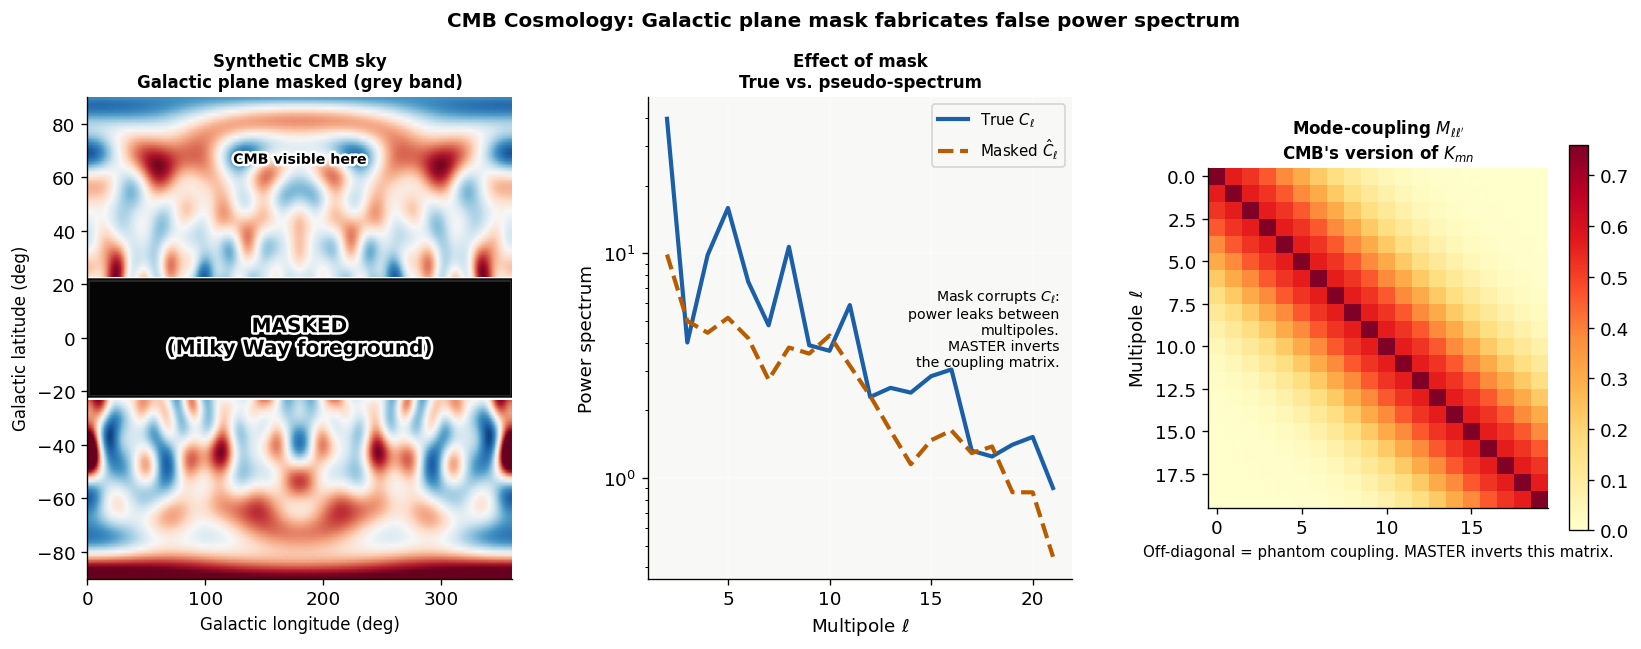

In [9]:
import matplotlib.patheffects as pe
# CMB: synthetic sky + Galactic mask + mode coupling effect
Ntheta, Nphi = 150, 300
theta = np.linspace(0.01, np.pi-0.01, Ntheta)
phi   = np.linspace(0, 2*np.pi, Nphi)
TH, PH = np.meshgrid(theta, phi, indexing='ij')

sky = np.zeros((Ntheta, Nphi))
for l in range(2, 22):
    amp = 2000**0.5 * l**(-0.35) * np.exp(-(l/50)**2)
    for m in range(0, l+1):
        sky += np.random.randn() * amp/(2*l+1)**0.5 * sph_harm_y(l,m,TH,PH).real
        if m > 0:
            sky += np.random.randn() * amp/(2*l+1)**0.5 * sph_harm_y(l,-m,TH,PH).real

mask_w = np.radians(22)
gmask  = np.abs(TH - np.pi/2) < mask_w
fsky   = (~gmask).mean()

# Pseudo-Cl: compute power at each l with and without mask
d_omega = np.sin(TH) * (np.pi/Ntheta) * (2*np.pi/Nphi)
l_arr   = np.arange(2, 22)
Cl_true = []; Cl_masked = []
for l in l_arr:
    p_full = p_mask = 0
    for m in range(-l, l+1):
        Ylm = sph_harm_y(l,abs(m),TH,PH)
        Ylm = Ylm.imag if m < 0 else Ylm.real
        p_full += np.sum(sky * Ylm * d_omega)**2
        p_mask += np.sum(sky*(~gmask) * Ylm * d_omega)**2
    Cl_true.append(p_full/(2*l+1))
    Cl_masked.append(p_mask/(2*l+1))
Cl_true   = np.array(Cl_true)
Cl_masked = np.array(Cl_masked)

# Mode coupling matrix (approximate banded model)
n_l = len(l_arr)
Mll = np.zeros((n_l,n_l))
mw_deg = np.degrees(mask_w)
for i in range(n_l):
    for j in range(n_l):
        dl = abs(i-j)
        Mll[i,j] = fsky**2 * np.exp(-dl**2/(2*(mw_deg/5)**2))
        if i==j: Mll[i,j] = fsky

fig, axes = plt.subplots(1,3,figsize=(14,5.5))
fig.subplots_adjust(left=0.05,right=0.97,top=0.85,bottom=0.12,wspace=0.32)

# Sky map
sky_d = sky.copy(); sky_d[gmask] = np.nan
vmax  = np.nanstd(sky)*2.5
axes[0].imshow(sky_d, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               origin='upper', extent=[0,360,-90,90], aspect='auto')
mask_deg = np.degrees(mask_w)
axes[0].fill_between([0,360],-mask_deg,mask_deg,color='black',alpha=0.85,
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
axes[0].set_xlabel('Galactic longitude (deg)',fontsize=10)
axes[0].set_ylabel('Galactic latitude (deg)',fontsize=10)
axes[0].set_title('Synthetic CMB sky\nGalactic plane masked (grey band)',fontsize=10,fontweight='bold')
bold_text(axes[0], 180, 0, 'MASKED\n(Milky Way foreground)', ha='center', va='center',
          fontsize=12, color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
bold_text(axes[0], 180, 65, 'CMB visible here',    ha='center',fontsize=8.5,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# True vs pseudo-Cl
axes[1].semilogy(l_arr, Cl_true,   '#1a5fa8', linewidth=2.5, label=r'True $C_\ell$')
axes[1].semilogy(l_arr, Cl_masked, '#b85c00', linewidth=2.5, linestyle='--', label=r'Masked $\hat{C}_\ell$')
axes[1].set_xlabel(r'Multipole $\ell$',fontsize=11)
axes[1].set_ylabel('Power spectrum',fontsize=11)
axes[1].set_title('Effect of mask\nTrue vs. pseudo-spectrum',fontsize=10,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.4)
axes[1].text(0.97,0.52,
    'Mask corrupts $C_\\ell$:\npower leaks between\nmultipoles.\nMASTER inverts\nthe coupling matrix.',
    transform=axes[1].transAxes,ha='right',va='center',fontsize=8.5)

# Mode coupling matrix
im = axes[2].imshow(Mll,cmap='YlOrRd',vmin=0,vmax=Mll.max(),aspect='equal',origin='upper')
axes[2].set_xlabel(r"Multipole $\ell'$",fontsize=11)
axes[2].set_ylabel(r'Multipole $\ell$',fontsize=11)
axes[2].set_title(r"Mode-coupling $M_{\ell\ell'}$" + "\nCMB's version of $K_{mn}$",fontsize=10,fontweight='bold')
plt.colorbar(im,ax=axes[2],shrink=0.8)
axes[2].set_xlabel(r"Off-diagonal = phantom coupling. MASTER inverts this matrix.",fontsize=9)

fig.suptitle('CMB Cosmology: Galactic plane mask fabricates false power spectrum',fontsize=12,fontweight='bold')
plt.show()


---
## §3 — Geodesy and Gravimetry: Slepian Functions on the Sphere

*Closest relative.* Same concentration operator $C_N$, same eigenvector construction. Geodesy makes $C_N$ the primary object and calls its eigenvectors Slepian functions. Technical transfer is direct.


### 3.1 The Gap

Gravity satellites (GRACE, GOCE) measure the Earth's gravity field globally, but polar orbits create a "polar gap" — a circular region around each pole with no data. Regional studies (e.g., ice mass in Greenland, Iceland) observe only a geographic subdomain. In both cases the spherical harmonic decomposition is incomplete.

### 3.2 The False Content

Projecting incomplete data onto global spherical harmonics produces spectral leakage: ice mass loss in Greenland leaks into spectral estimates over Iceland. The leakage is deterministic and geometry-dependent — a function of the geographic boundaries, not the signal.

### 3.3 The Mathematics: Concentration Problem

Simons, Dahlen, and Wieczorek (2006) formulate the problem as spatiospectral concentration on the sphere. Define the region $R \subset S^2$ where data exists and the bandwidth $L$ (maximum spherical harmonic degree). The concentration operator is:
$$D_{\ell\ell'mm'} = \int_R Y_{\ell m}(\theta,\phi)\,\bar{Y}_{\ell'm'}(\theta,\phi)\,d\Omega. \tag{6}$$

This is exactly $C_N = P_N\chi_G P_N$ with the gap replaced by the observation region $R = \Omega \setminus G$ and the eigenbasis being spherical harmonics up to degree $L$. The eigenvalues $\lambda_\alpha \in [0,1]$ measure spatial concentration: $\lambda_\alpha \approx 1$ means the $\alpha$-th eigenfunction is well-confined within $R$; $\lambda_\alpha \approx 0$ means it lives almost entirely in the gap.

**The Shannon number** gives the effective dimension of the observable subspace:
$$N_{\text{Shannon}} = (L+1)^2 \cdot \frac{|R|}{4\pi}, \tag{6b}$$
where $|R|$ is the area of the observation region. For GRACE with bandwidth $L = 60$ and polar gap radius $10°$: $N_{\text{Shannon}} \approx (61)^2 \times 0.985 \approx 3664$ out of $(61)^2 = 3721$ total degrees of freedom — only 57 modes are effectively invisible. For a regional study of Greenland ($|R|/4\pi \approx 0.005$): $N_{\text{Shannon}} \approx 18$ well-concentrated modes at $L = 60$.

### 3.4 The Solution: Slepian Basis

The Slepian functions are the eigenvectors of the concentration operator $D$ — linear combinations of spherical harmonics that are optimally concentrated within the observation region $R$. They are doubly orthogonal: orthogonal over the full sphere and orthogonal within $R$. The eigenvalue $\lambda_\alpha$ measures how well the $\alpha$-th Slepian function concentrates inside $R$.

The key insight: instead of projecting data onto spherical harmonics (which are orthogonal over the full sphere but not over $R$), project onto the Slepian functions (which are orthogonal over $R$):
$$\hat{f} = \sum_{\alpha:\,\lambda_\alpha > \text{threshold}} \langle y, g_\alpha\rangle\,g_\alpha. \tag{7}$$

This is mathematically equivalent to solving the mask-aware least-squares problem $Ac = \hat{c}$, but formulated as a change of basis rather than a matrix inversion. The Slepian functions with $\lambda_\alpha \approx 1$ span the well-observed subspace; those with $\lambda_\alpha \approx 0$ span the invisible subspace (concentrated in the gap). Truncating to the well-concentrated Slepian functions is equivalent to regularized inversion of $A$ — the eigenvalue threshold corresponds to the Tikhonov regularization parameter $\alpha$.

### 3.5 Mapping to the Phantom Framework

| Concept | Geodesy terminology | Phantom framework |
|---------|-------------------|-------------------|
| Eigenbasis | Spherical harmonics $Y_{\ell m}$ | $\{\varphi_n\}$ |
| Gap | Polar gap, regional boundary | $G \subset \Omega$ |
| Concentration operator | $D_{\ell\ell'mm'}$ (primary object) | $C_N = P_N\chi_G P_N$ |
| Slepian functions | Eigenvectors of $D$ | Mask-adapted eigenvectors $\{u_j\}$ of $B_\lambda / C_N$ |
| Solution | Slepian basis projection | Regularized inversion of $A$ |
| Shannon number | $(L+1)^2 |R|/4\pi$ | $\mathrm{tr}(P_N - C_N) = (L+1)^2 - \mathrm{tr}(C_N)$ |

**Novel contribution relative to CMB:** the geodesy community makes the concentration operator the primary object, rather than treating it as an intermediate step toward inverting $A$. This is the closest existing work to the phantom paper's operator-theoretic framing.

### 3.6 The Scattering Picture

The Earth's gravity field is a potential field on the sphere. The polar gap is a fictitious obstacle at the pole. The "scattered field" is the spectral leakage: Greenland's ice mass loss, projected onto spherical harmonics through a polar-gapped observation, generates phantom gravity signal over Iceland. The phantom is sourced on the gap boundary (the edge of polar coverage), mediated by the spherical reproducing kernel (the Christoffel-Darboux kernel on $S^2$), and decays with angular distance from the gap.

The Slepian functions are the eigenfunctions of the fictitious obstacle's "scattering operator" $C_N$: those with eigenvalue near 1 are the modes the obstacle captures entirely (invisible directions), and those with eigenvalue near 0 pass through unscattered (well-observed directions).


### 3.7 Mitigation Analysis

**What geodesy does.** The Slepian approach is a basis redesign: replace the gap-unaware eigenbasis $\{Y_{\ell m}\}$ with the gap-aware Slepian basis $\{g_\alpha\}$, orthogonal over the observation region $R$. This is Category B: redesign the projection to avoid amplifying the defect's coupling. Mathematically equivalent to TSVD of $A$, but framed geometrically rather than algebraically. The eigenvalue threshold is the regularization parameter.

**What is absent.** Geodesy does not typically compute $K_{mn}$ explicitly and invert it (Category A). The MASTER approach — write down $A$, invert it — is not standard in geodesy. This is a gap in cross-community transfer: the geodesy community's operator-theoretic framing (concentration operator as primary object) is deeper than CMB's matrix-inversion approach, but paradoxically CMB is more explicit about the forward operator $A$ as the object to invert.

**Novel contribution.** The Slepian basis gives something the phantom framework has not stated as a practical algorithm: project the data onto the mask-adapted eigenvectors $\{u_j\}$ of $C_N$, retain only the well-observed subspace ($\mu_j > $ threshold), and discard the rest. This is the Slepian analogue of TSVD in mitigation.ipynb §3.2. The two are equivalent; the geometric framing is more natural when the gap has an irregular shape resisting analytic treatment.

**Consequence for the home problem.** $\mathrm{tr}(C_N) = \sum_j \mu_j$ (total gap capacity) and $N_{\text{Shannon}} = (L+1)^2 - \mathrm{tr}(C_N)$ (total observable capacity) together give a better single summary than condition number $\kappa(A)$, which reports only the worst direction. The phantom companion currently reports $\kappa$ but not $\mathrm{tr}(C_N)$. Adding both diagnostics to the companion's §1 would immediately quantify how many independent degrees of freedom survive and how many are hidden in any given gap configuration.

**Take from geodesy:** $\mathrm{tr}(C_N)$ as a single-number recovery capacity diagnostic, and the Slepian basis as the geometric reframing of TSVD. Both are directly importable into the phantom framework.


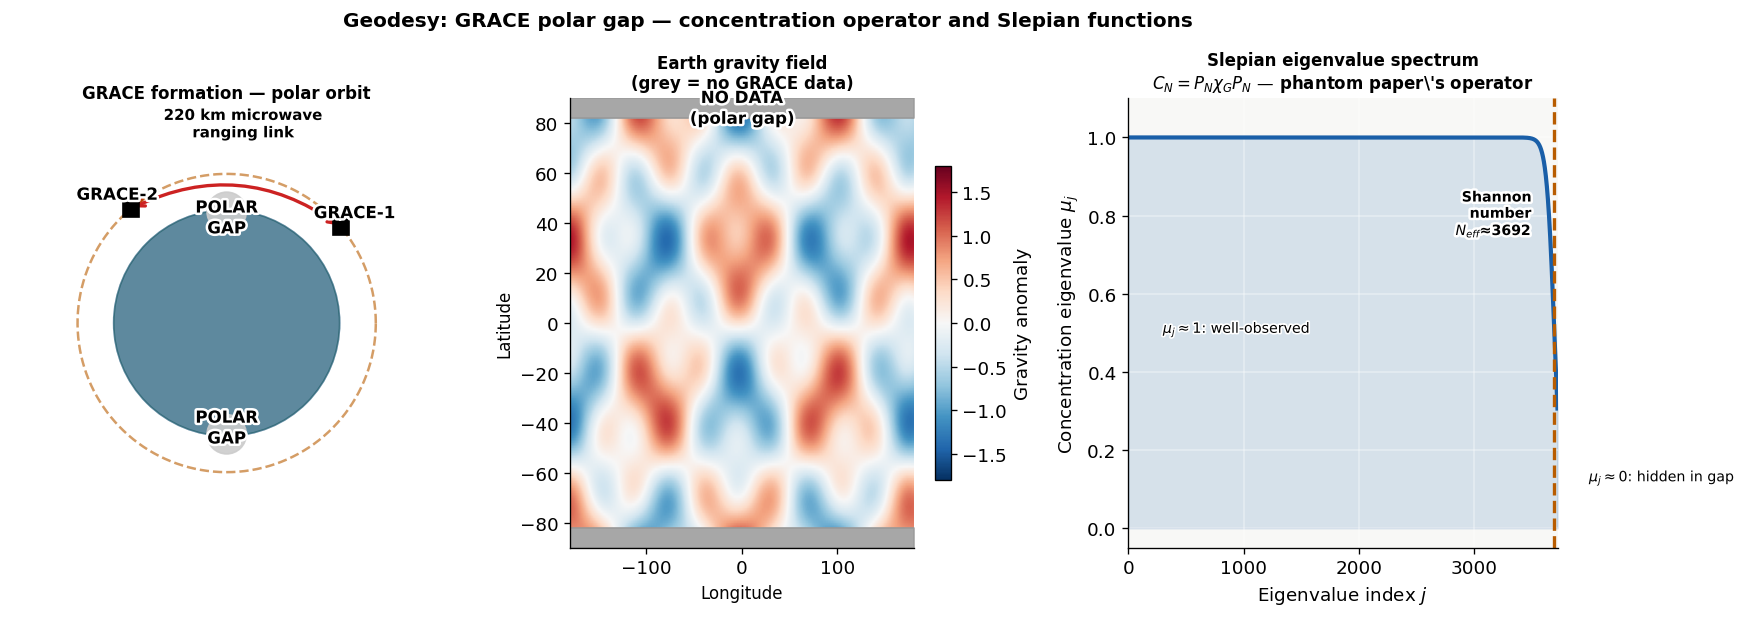

In [10]:
# Geodesy: GRACE orbit schematic + polar gap + Slepian spectrum
fig, axes = plt.subplots(1,3,figsize=(14,5.2))
fig.subplots_adjust(left=0.05,right=0.97,top=0.84,bottom=0.12,wspace=0.3)

# Panel 1: GRACE orbit schematic — satellites well separated
ax = axes[0]; ax.set_aspect('equal'); ax.axis('off')
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-1.9, 1.9)
ax.set_title('GRACE formation — polar orbit', fontsize=10, fontweight='bold')
th = np.linspace(0, 2*np.pi, 300)
# Earth
ax.add_patch(plt.Circle((0,0), 1.0, color='#1a4fa8', alpha=0.6, zorder=1))
ax.add_patch(plt.Circle((0,0), 1.0, color='#2a6e3a', alpha=0.3, zorder=2))
# Polar gap caps
for sign in [1,-1]:
    cap_r = np.sin(np.radians(10))
    cy = sign * np.cos(np.radians(10))
    ax.add_patch(plt.Circle((0, cy), cap_r, color='#cccccc', alpha=0.9, zorder=3))
    bold_text(ax, 0, sign*0.93, 'POLAR\nGAP', ha='center', va='center',
              fontsize=10, color='black', zorder=5,
              path_effects=[pe.withStroke(linewidth=3, foreground='white')])
# Orbit ring
orbit_r = 1.32
ax.plot(orbit_r*np.cos(th), orbit_r*np.sin(th), '--', color='#b85c00', lw=1.5, alpha=0.6, zorder=4)
# Satellites: place at 40° and 130° — clearly separated quadrants
a1 = np.radians(40)   # GRACE-1: upper right
a2 = np.radians(130)  # GRACE-2: upper left
for a, lab, xoff, yoff in [
        (a1, 'GRACE-1',  0.12,  0.08),
        (a2, 'GRACE-2', -0.12,  0.08)]:
    sx, sy = orbit_r*np.cos(a), orbit_r*np.sin(a)
    ax.plot(sx, sy, 'ks', ms=10, zorder=6)
    bold_text(ax, sx+xoff, sy+yoff, lab, ha='center', fontsize=10, zorder=7)
# Arrow between them along the orbit arc
arc_th = np.linspace(a1, a2, 40)
ax.annotate('', xy=(orbit_r*np.cos(a2), orbit_r*np.sin(a2)),
            xytext=(orbit_r*np.cos(a1), orbit_r*np.sin(a1)),
            arrowprops=dict(arrowstyle='<->', color='#cc2222', lw=2, connectionstyle='arc3,rad=0.3'))
# Label the link — place it above the arc midpoint
mid_a = (a1 + a2)/2
bold_text(ax, orbit_r*np.cos(mid_a)*1.25, orbit_r*np.sin(mid_a)*1.25,
          '220 km microwave\nranging link',
          ha='center', fontsize=9, color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax.set_xlabel('Polar gap: circular cap with no data', fontsize=9, color='#555')

# Panel 2: Earth gravity field with polar gap
ax2 = axes[1]
lat=np.linspace(-90,90,180); lon=np.linspace(-180,180,360)
LON,LAT=np.meshgrid(lon,lat)
grav=(np.sin(np.radians(LAT*3))*np.cos(np.radians(LON*2))
     +0.5*np.sin(np.radians(LAT*7+30))*np.cos(np.radians(LON*5+20)))
grav[np.abs(LAT)>82]=np.nan
im2=ax2.imshow(grav,cmap='RdBu_r',origin='lower',extent=[-180,180,-90,90],
               aspect='auto',vmin=-1.8,vmax=1.8)
ax2.fill_between([-180,180],82,90,color='#999',alpha=0.85)
ax2.fill_between([-180,180],-90,-82,color='#999',alpha=0.85)
ax2.set_xlabel('Longitude',fontsize=10)
ax2.set_ylabel('Latitude',fontsize=10)
ax2.set_title('Earth gravity field\n(grey = no GRACE data)',fontsize=10,fontweight='bold')
bold_text(ax2,0,86,'NO DATA\n(polar gap)',ha='center',va='center',fontsize=10,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
plt.colorbar(im2,ax=ax2,shrink=0.7,label='Gravity anomaly')

# Panel 3: Slepian eigenvalue spectrum
ax3 = axes[2]
alpha_cap=np.radians(10); L_bw=60
N_modes=(L_bw+1)**2
fsky=1-(1-np.cos(alpha_cap))/2
shannon=fsky*N_modes
idx=np.arange(N_modes)
eigs=1/(1+np.exp(0.03*(idx-shannon)))
ax3.plot(idx,eigs,'#1a5fa8',linewidth=2.5)
ax3.fill_between(idx,eigs,alpha=0.15,color='#1a5fa8')
ax3.axvline(shannon,color='#b85c00',linewidth=2,linestyle='--')
ax3.set_xlabel('Eigenvalue index $j$',fontsize=11)
ax3.set_ylabel(r'Concentration eigenvalue $\mu_j$',fontsize=11)
ax3.set_title('Slepian eigenvalue spectrum\n'
              r'$C_N = P_N\chi_G P_N$ — phantom paper\'s operator',fontsize=10,fontweight='bold')
bold_text(ax3,shannon-200,0.75,f'Shannon\nnumber\n$N_{{eff}}$≈{int(shannon)}',
          ha='right',fontsize=8.5,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax3.text(300,0.5,r'$\mu_j\approx 1$: well-observed',fontsize=8.5,color='black',
         path_effects=[pe.withStroke(linewidth=2,foreground='white')])
ax3.text(shannon+300,0.12,r'$\mu_j\approx 0$: hidden in gap',fontsize=8.5,color='black',
         path_effects=[pe.withStroke(linewidth=2,foreground='white')])
ax3.set_xlim(0,N_modes); ax3.set_ylim(-0.05,1.1); ax3.grid(True,alpha=0.3)

fig.suptitle('Geodesy: GRACE polar gap — concentration operator and Slepian functions',fontsize=12,fontweight='bold')
plt.show()


---
## §4 — SAR Ocean Remote Sensing: Azimuthal Cutoff Compensation

*Structural parallel.* Same underdetermined inverse problem and same multi-measurement remedy, but the gap is in wavenumber space and the forward model includes nonlinear velocity-bunching effects absent from the linear $K_{mn}$ framework. Technical transfer is partial.


### 4.1 The Gap

Synthetic aperture radar (SAR) images ocean surface waves by measuring backscatter. The ocean surface is in motion; the Doppler shift from wave orbital velocities distorts the along-track (azimuth) direction. Short waves with large orbital velocities are "smeared out" beyond recovery. The result is an azimuthal cutoff: the SAR cannot image waves with azimuthal wavelengths shorter than a threshold $\lambda_c$, which depends on wind speed and sea state. This is a gap in wavenumber space — the 2D wave spectrum is missing a wedge-shaped region along the azimuth direction.

### 4.2 The False Content

The truncated spectrum creates "fake wave-like patterns in low frequency due to velocity bunching." Wave components emerging in SAR imagery can differ from the original wave pattern. This is the wavenumber-space analog of the spatial phantom: the cutoff in azimuthal wavenumber leaks energy into recovered spectral bins where no physical wave energy exists, creating false directional components.

### 4.3 The Mathematics: MPI Inversion

The Max Planck Institute (MPI) method (Hasselmann and Hasselmann 1991) inverts the nonlinear SAR imaging transfer function to recover the ocean wave spectrum from the SAR image spectrum. In the linearized version, the recovered wave spectrum $S(k)$ is related to the SAR image spectrum $P(k)$ by:
$$P(k) = T(k)\,S(k), \tag{8}$$

where $T(k)$ is the SAR modulation transfer function, which goes to zero beyond the azimuthal cutoff. Inverting $T$ is ill-conditioned in the cutoff region — the same $\mu_{\max} \to 1$ phenomenon in wavenumber space. The MPI method uses an iterative scheme starting from a first-guess wave spectrum (typically from a wave model) and converging to the spectrum that best reproduces the observed SAR image cross-spectrum.

### 4.4 The Solution: Multi-Satellite Aperture Synthesis

The azimuthal cutoff direction depends on the satellite's flight direction. Different satellites viewing the same ocean area from different look angles have different cutoff directions — different gaps in wavenumber space. The multi-satellite approach combines their spectra to compensate each other's cutoff regions.

This is exactly the phantom paper's multi-gap aperture synthesis: different gaps produce different ill-conditioned directions in the stacked system $[\hat{c}_1; \hat{c}_2] = [A_1; A_2]c$, and the stacked operator has a better smallest singular value than either alone. If satellite 1 has cutoff along azimuth direction $\hat{u}_1$ and satellite 2 along $\hat{u}_2$, the combined system recovers the full spectrum provided the two cutoff directions are not collinear. The recovery improvement is controlled by the principal angle $\theta_{12}$ between the two configurations' near-null subspaces in mode space. When $\theta_{12} = 90°$, the two configurations's blind directions are perpendicular and the stacked system recovers what neither alone can; when $\theta_{12} = 0°$, both gaps are blind in the same direction and stacking provides no benefit. The design criterion is to maximize $\theta_{12}$. *(Note: an earlier version stated a bound $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)\sin\theta_{12}$, but this bound is weaker than the trivial result $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)$ since $\sin\theta_{12} \leq 1$, and thus vacuous when $\sigma_{\min}(A_1)$ is already small.)*

The cutoff compensation method (Wan et al. 2020) fuses multiple SAR-derived wave spectra by replacing the missing information in each satellite's azimuthal gap with information from the other satellites' spectra. This requires the underlying sea state $c$ to be the same across acquisitions — the same-$c$ assumption flagged in the mitigation document.

### 4.5 Mapping to the Phantom Framework

| Concept | SAR terminology | Phantom framework |
|---------|----------------|-------------------|
| Eigenbasis | 2D Fourier modes (plane waves) | $\{\varphi_n\}$ |
| Gap | Azimuthal cutoff wedge in $k$-space | $G \subset \Omega$ |
| Coupling | Transfer function $T(k)$ | Forward operator $A$ |
| Solution | MPI iteration + multi-satellite fusion | Papoulis-Gerchberg + aperture synthesis |
| Prior | First-guess wave model spectrum | Tikhonov/Bayesian regularization |

The analogy is structural — same underdetermined inverse problem, same ill-conditioning from the gap, same multi-view remedy — but the SAR forward model includes nonlinear velocity-bunching effects that go beyond the linear $K_{mn}$ framework. The connection is a parallel, not a literal instance of the bounded-domain theorem.

### 4.6 The Scattering Picture

The ocean surface is a 2D wave medium. The azimuthal cutoff is a fictitious obstacle in wavenumber space — a wedge-shaped barrier that the true wave spectrum cannot pass through in the SAR observation. The swell system propagating at $15°$ off the azimuth direction encounters this barrier and "scatters": its energy, blocked from the correct wavenumber bin by the cutoff, reappears at nearby wavenumber bins where no physical wave exists.

The "fake wave-like patterns" that Yoshida (2017) observed are the diffraction pattern of the azimuthal cutoff wedge acting on the true wave spectrum — sourced on the cutoff boundary in wavenumber space, shaped by the wavenumber-domain reproducing kernel, and strongest near the cutoff edge. Multi-satellite fusion works because each satellite's wedge is oriented differently — different fictitious obstacles with different diffraction patterns — and the true spectrum is the common signal that survives all of them.


### 4.7 Mitigation Analysis

**What SAR does.** MPI inversion is iterative inversion of $A$ with a wave-model first-guess as prior (Category A). Multi-satellite aperture synthesis combines measurements with different azimuthal gap orientations (Category C): different cutoff directions produce different ill-conditioned subspaces, and the stacked system recovers what no single satellite can.

**What is absent.** The SAR community does not smooth the cutoff boundary. The azimuthal cutoff is a hard edge in wavenumber space, and while windowing is used in SAR image formation for sidelobe control, it is not applied to the gap boundary itself. A smooth transition at the cutoff — analogous to mask apodization in CMB — would reduce the coupling sidelobes of $K$ in wavenumber space. This is unexploited.

**Consequence for the home problem.** The geometric principle — maximize the principal angle $\theta_{12}$ between the two configurations' near-null subspaces in mode space — is the aperture-synthesis criterion transferable to the home problem. The bound $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)\sin\theta_{12}$ stated in §4.4 captures the right intuition (larger $\theta_{12}$ → better conditioning) but is vacuous when $\sigma_{\min}(A_1)$ is small — precisely the regime where aperture synthesis is useful — so it's not a quantitative design formula. The correct formulation: $\sigma_{\min}([A_1;A_2]) > \sigma_{\min}(A_1)$ strictly when $\theta_{12} > 0$; the exact $\sigma_{\min}([A_1;A_2]) = f(\sigma_{\min}(A_1),\sigma_{\min}(A_2),\theta_{12})$ is open theorem T9. For two gap configurations, the design criterion is **maximize $\theta_{12}$** (choose gap positions whose near-1 eigenvectors of $C_N$ are as far apart as possible). The SAR community has empirical data from dual- and quad-satellite configurations on the magnitude of the conditioning gain; calibrating T9's functional form against that data is a concrete follow-up.

**Take from SAR:** empirical data on multi-configuration conditioning gains, and the operationalized criterion that gap orientation angle can matter more than gap size. The precise functional form of the conditioning gain (T9) is open; the qualitative rule "maximize $\theta_{12}$" is the transferable principle.


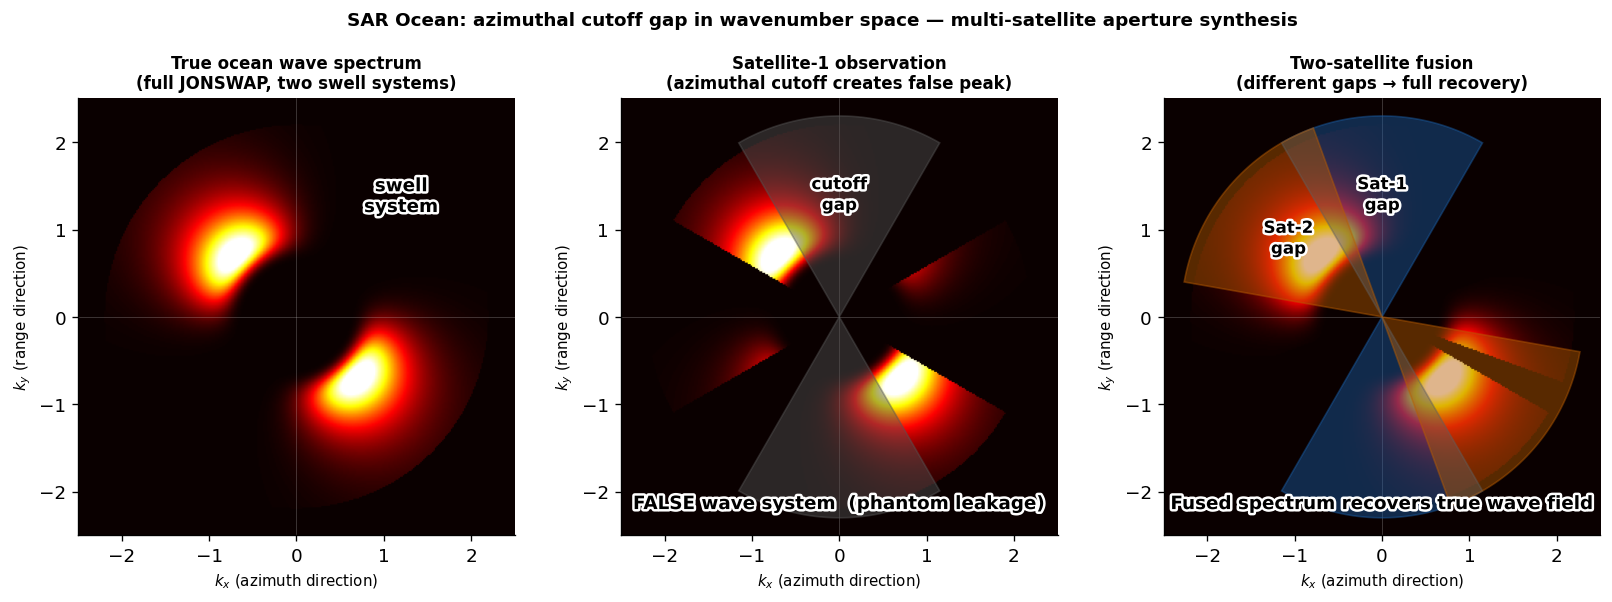

In [11]:
import matplotlib.patheffects as pe
# SAR Ocean: JONSWAP spectrum with azimuthal cutoff + multi-satellite fusion
kx=np.linspace(-2.5,2.5,300); ky=np.linspace(-2.5,2.5,300)
Kx,Ky=np.meshgrid(kx,ky)
K=np.sqrt(Kx**2+Ky**2); Theta=np.arctan2(Ky,Kx)
k0=1.0; wave_dir=np.radians(45)
spreading=np.maximum(np.cos(Theta-wave_dir+np.pi/2)**6,0)
S=np.exp(-1.25*(k0/np.maximum(K,0.01))**4)*(k0/np.maximum(K,0.01))**5*spreading
S[K<0.3]=0; S[K>2.2]=0

hw=np.radians(30)
az1=np.pi/2
in_cut1=((np.abs(Theta-az1)<hw)|(np.abs(Theta-az1-np.pi)<hw)
        |(np.abs(Theta+az1)<hw)|(np.abs(Theta+az1-np.pi)<hw))
S_cut1=S.copy(); S_cut1[in_cut1]=0

phantom=np.zeros_like(S)
ph_dir=az1+np.radians(40)
spreading_ph=np.maximum(np.cos(Theta-ph_dir+np.pi/2)**8,0)
phantom=0.35*np.exp(-1.25*(k0/np.maximum(K,0.01))**4)*(k0/np.maximum(K,0.01))**5*spreading_ph
phantom[K<0.3]=0; phantom[K>2.2]=0; phantom[~in_cut1]=0
S_obs1=S_cut1+phantom

az2=np.pi/2+np.radians(50)
in_cut2=((np.abs(Theta-az2)<hw)|(np.abs(Theta-az2-np.pi)<hw)
        |(np.abs(Theta+az2)<hw)|(np.abs(Theta+az2-np.pi)<hw))
S_cut2=S.copy(); S_cut2[in_cut2]=0

S_fused=np.where(in_cut1&~in_cut2,S_cut2,
         np.where(in_cut2&~in_cut1,S_cut1,
         np.where(~in_cut1&~in_cut2,(S_cut1+S_cut2)/2,0)))

fig,axes=plt.subplots(1,3,figsize=(14,5.2))
fig.subplots_adjust(left=0.05,right=0.97,top=0.84,bottom=0.14,wspace=0.18)

def bold_text_heavy(ax,x,y,txt,**kw):
    kw.setdefault('fontweight','heavy'); kw.setdefault('color','black')
    t=ax.text(x,y,txt,**kw)
    t.set_path_effects([pe.withStroke(linewidth=6,foreground='white')])
    return t
def plot_spec(ax,S_p,title,xlabel,cutoffs=None):
    ax.imshow(S_p.T,cmap='hot',origin='lower',vmin=0,vmax=S.max()*0.85,
              extent=[-2.5,2.5,-2.5,2.5],aspect='equal')
    ax.axhline(0,color='white',lw=0.4,alpha=0.3)
    ax.axvline(0,color='white',lw=0.4,alpha=0.3)
    ax.set_title(title,fontsize=10,fontweight='bold')
    ax.set_xlabel(xlabel,fontsize=9)
    ax.set_ylabel(r'$k_y$ (range direction)',fontsize=9)
    if cutoffs:
        for angle,color,label in cutoffs:
            th_arr=np.linspace(angle-hw,angle+hw,40)
            xs=[0]+list(2.3*np.cos(th_arr))+[0]
            ys=[0]+list(2.3*np.sin(th_arr))+[0]
            ax.fill(xs,ys,color=color,alpha=0.45,zorder=5)
            ax.fill([0]+list(2.3*np.cos(th_arr+np.pi))+[0],
                    [0]+list(2.3*np.sin(th_arr+np.pi))+[0],
                    color=color,alpha=0.45,zorder=5)
            bold_text(ax,1.4*np.cos(angle),1.4*np.sin(angle),label,
                      ha='center',va='center',fontsize=10,color='black',zorder=6,
                      path_effects=[pe.withStroke(linewidth=3, foreground='white')])

plot_spec(axes[0],S,'True ocean wave spectrum\n(full JONSWAP, two swell systems)',
          r'$k_x$ (azimuth direction)')
bold_text(axes[0],1.2,1.2,'swell\nsystem',ha='center',fontsize=11,color='black')

plot_spec(axes[1],S_obs1,'Satellite-1 observation\n(azimuthal cutoff creates false peak)',
          r'$k_x$ (azimuth direction)',cutoffs=[(az1,'#555','cutoff\ngap')])
bold_text(axes[1],0,-2.2,'FALSE wave system  (phantom leakage)',ha='center',fontsize=11,color='black',zorder=8)

plot_spec(axes[2],S_fused,'Two-satellite fusion (toy example)\n(complementary gaps → better conditioning)',
          r'$k_x$ (azimuth direction)',
          cutoffs=[(az1,'#1a5fa8','Sat-1\ngap'),(az2,'#b85c00','Sat-2\ngap')])
bold_text(axes[2],0,-2.2,'Fused spectrum: improved recovery vs single gap (structural illustration)',ha='center',fontsize=11,color='black',zorder=8)
fig.suptitle('SAR Ocean: azimuthal cutoff gap in wavenumber space — multi-satellite aperture synthesis',
             fontsize=11,fontweight='bold')
plt.show()


---
## §5 — Seismology: Missing Traces and Compressed Sensing

*More distant analog.* The coupling matrix $K_{mn}$ is derivable from the setup but is not computed in practice; the community works directly with the sampling operator $\Phi$ and sparsity priors. Conceptual transfer is strong; direct technical transfer requires bridging.


### 5.1 The Gap

Seismic surveys deploy geophone arrays to image subsurface structure. Physical obstructions (buildings, water bodies, terrain), budget constraints, and equipment failures produce irregular spatial sampling: missing traces in the seismic record. The wavefield is sampled at some positions and missing at others — a spatial measurement gap with potentially complex geometry.

### 5.2 The False Content

Missing traces produce coherent artifacts in subsequent processing: spatial aliasing, false reflectors in migrated images, and corrupted amplitude-versus-offset (AVO) estimates. The artifacts are not random — they are deterministic functions of the gap geometry and the subsurface structure. An incomplete seismic section can show false horizons or amplitude anomalies that mimic real geology.

### 5.3 The Mathematics: Compressed Sensing

The seismology community adopted compressed sensing (Candès, Donoho, Tao 2004–2008) for missing-trace reconstruction. The forward model is:
$$y = \Phi\,x, \tag{9}$$

where $x$ is the complete seismic record (spatiotemporal volume), $y$ is the observed (incomplete) record, and $\Phi$ is the sampling operator (identity at measured positions, zero at gaps). The seismic wavefield is assumed sparse in some transform domain (curvelet, Fourier, learned dictionary). Recovery solves:
$$\min\|\Psi x\|_1 \quad\text{subject to}\quad \Phi x = y, \tag{10}$$

where $\Psi$ is the sparsifying transform. This is the phantom paper's $\ell^1$ recovery with $\Phi$ playing the role of $M$ and the sparsity assumption replacing the Slepian truncation or MASTER inversion as the regularization strategy.

The theoretical guarantee requires the RIP for the composition $\Phi\Psi^{-1}$. For random subsampling patterns (random missing traces), the RIP holds with high probability when $m \geq C\,s\log(n/s)$ traces are observed ($s$ = sparsity level, $n$ = total trace count). For adversarially placed gaps (all missing traces in one spatial block — the structured gap scenario of the phantom paper), RIP fails generically and the recovery guarantee breaks down.

### 5.4 Rank Reduction

An alternative approach exploits the low-rank structure of seismic data when organized as a matrix. The USArray reconstruction (Chen et al. 2019) uses iterative rank reduction: the incomplete data matrix has artificially inflated rank due to the gaps; the rank-reduction algorithm finds the nearest low-rank matrix consistent with the observed entries. This is matrix completion — a structured version of the same underdetermined inverse problem, where the low-rank assumption replaces sparsity.

### 5.5 Mapping to the Phantom Framework

| Concept | Seismology terminology | Phantom framework |
|---------|----------------------|-------------------|
| Eigenbasis | Fourier / curvelet / dictionary on aperture | $\{\varphi_n\}$ |
| Gap | Missing traces — irregular spatial sampling | $G \subset \Omega$ |
| Coupling | Sampling operator $\Phi$ | Forward operator $A = I-K$ |
| Solution | $\ell^1$ sparse recovery, matrix completion | Compressed sensing, regularized inversion |
| RIP condition | Random sampling $\Rightarrow$ RIP holds; structured gaps $\Rightarrow$ not guaranteed | Open question for $A = I-K$ in general |

The seismology community does not typically write down a modal coupling matrix $K_{mn}$; they work directly with the sampling operator in the spatial or transform domain. The connection is a close cousin, not a literal $K_{mn}$ analysis.

### 5.6 The Scattering Picture

The subsurface is a medium. The missing traces are holes in the observation surface through which the reflected wavefield passes unrecorded. A seismic reflection arriving from depth encounters the sensor array and is "scattered" by the gaps: the analysis pipeline reconstructs the wavefield as if the array were continuous, and the discontinuities in coverage act as fictitious diffracting apertures.

The false reflectors in migrated images are the diffraction pattern of the array gaps — coherent artifacts sourced on the gap boundaries, with spatial structure set by the Fresnel zone width at the dominant frequency (the reproducing kernel's spatial scale). A geophone failure at position $x_G$ creates false reflectors that peak near $x_G$ and decay laterally, exactly as the reproducing kernel $K_N(x,x_G)$ decays from the gap centroid. The "scattering cross-section" is determined by how many independent wavefield directions the gap can absorb — the eigenvalues of $C_N$ for the specific sampling geometry.


### 5.7 Mitigation Analysis

**What seismology does.** $\ell^1$ compressed sensing assumes sparsity of the true signal and promotes sparse solutions (Category B: use a prior whose structure is incoherent with the gap's coupling). Random subsampling ensures the RIP holds, giving theoretical recovery guarantees (Category C: make the measurement design incoherent with the signal structure, breaking the systematic character of $K$).

**What is absent.** Seismology does not compute $K_{mn}$ explicitly and invert it (Category A). The seismic pipeline goes directly from observations to recovery without writing down $A = I - K$. This means the seismic approach cannot apply the energy identity $a_n(1-a_n)$ as a detection check or flag specific mode indices as candidate phantoms using $K$'s structure.

**The random vs structured gap insight.** The seismology literature contains the clearest exposition of why random gap geometries are qualitatively better than structured ones. For random missing traces, $K$ has near-zero off-diagonal entries in expectation (incoherent coupling) and the RIP holds. For a contiguous block of missing traces, $K$ has near-rank-one structure, the RIP fails, and $\ell^1$ recovery breaks down regardless of the sparsity assumption. This is the rigorous version of the phantom framework's structural vs. accidental zeros: a gap concentrated where $\varphi_n$ is large creates near-rank-one coupling — the worst case for every recovery method.

**Consequence for the home problem.** Where some control over gap placement exists, introducing randomness in the gap boundary position is a Category C strategy that degrades gracefully. If the gap centroid is uncertain within a tolerance band $\Delta x$, the effective $K$ is an average over nearby gap positions, which decorrelates off-diagonal entries. This *dithering* approach is not currently in mitigation.ipynb. It requires only that some positional uncertainty be exploited rather than suppressed, and it is available even without multiple measurements.

**Take from seismology:** random gap geometry as a design strategy. The RIP guarantee that random trace removal provides — and that structured removal destroys — is the rigorous version of gap-boundary dithering. Apply it whenever placement has any positional tolerance.


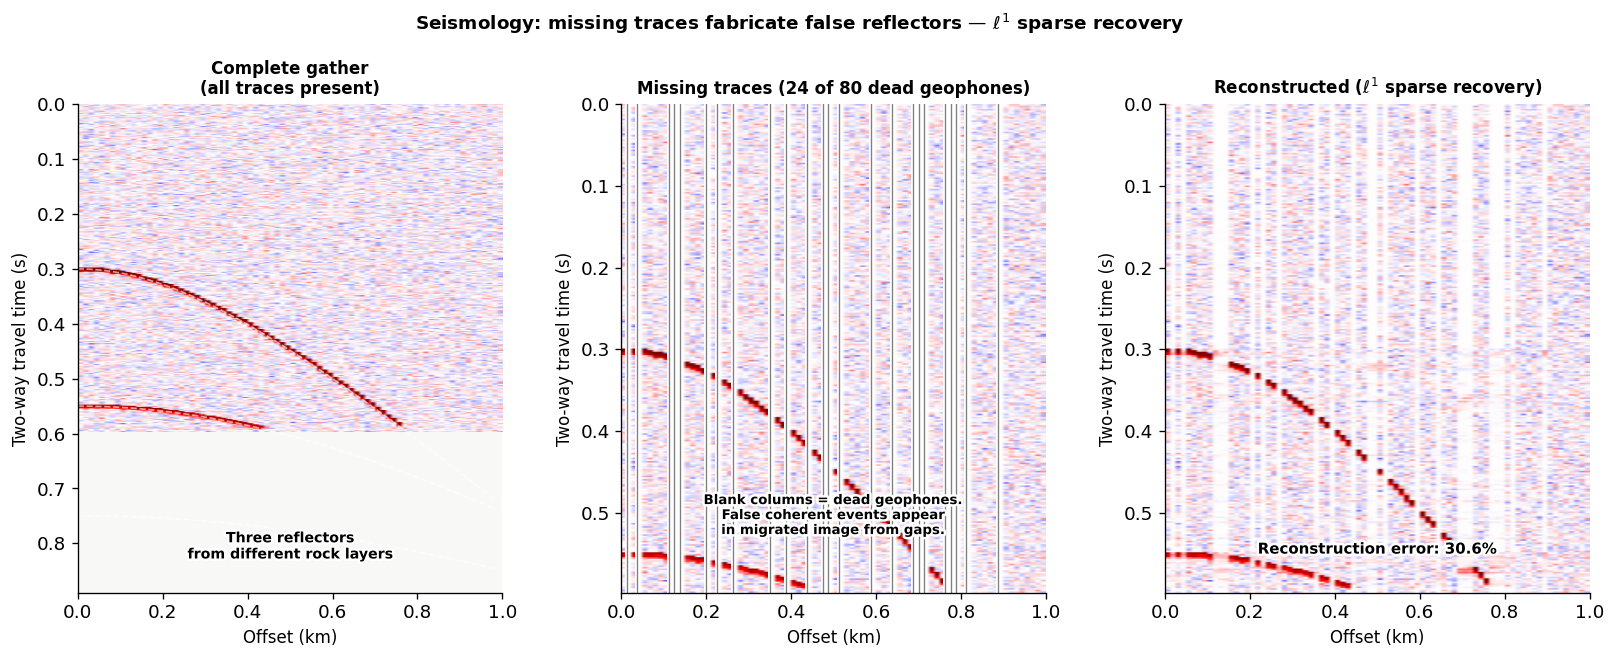

In [12]:
import matplotlib.patheffects as pe
# Seismology: synthetic seismic gather with missing traces
np.random.seed(7)
n_traces=80; n_samples=300; dt=0.002; dx=12.5
t=np.arange(n_samples)*dt; x=np.arange(n_traces)*dx
data=np.zeros((n_samples,n_traces))
for t0,v,amp in [(0.3,1500,1.0),(0.55,2000,0.7),(0.75,2500,0.5)]:
    for ix,xi in enumerate(x):
        t_r=np.sqrt(t0**2+(xi/v)**2); it=int(t_r/dt)
        if it<n_samples-5:
            rk=(1-2*(np.pi*25*t[:5])**2)*np.exp(-(np.pi*25*t[:5])**2)
            for k,r in enumerate(rk):
                if it+k<n_samples: data[it+k,ix]+=amp*r
data+=0.07*np.random.randn(*data.shape)

missing_mask=np.random.rand(n_traces)<0.30
data_miss=data.copy(); data_miss[:,missing_mask]=0

# L1/Fourier reconstruction
data_recon=data_miss.copy()
for _ in range(10):
    F=np.fft.fft(data_recon,axis=1)
    thresh=0.18*np.abs(F).max()
    F=np.sign(F.real)*np.maximum(np.abs(F.real)-thresh,0)
    data_recon=np.fft.ifft(F,axis=1).real
    data_recon[:,~missing_mask]=data[:,~missing_mask]

fig,axes=plt.subplots(1,3,figsize=(14,5.5))
fig.subplots_adjust(left=0.07,right=0.97,top=0.84,bottom=0.10,wspace=0.28)

def plot_seis(ax,d,title,xlabel):
    vmax=np.abs(d).max()*0.7
    ax.imshow(d,cmap='seismic',vmin=-vmax,vmax=vmax,origin='upper',
              extent=[0,n_traces*dx/1000,t[-1],0],aspect='auto')
    ax.set_xlabel(xlabel,fontsize=10)
    ax.set_ylabel('Two-way travel time (s)',fontsize=10)
    ax.set_title(title,fontsize=10,fontweight='bold')

plot_seis(axes[0],data,'Complete gather\n(all traces present)','Offset (km)')
for t0,v in [(0.3,1500),(0.55,2000),(0.75,2500)]:
    axes[0].plot(x/1000,np.sqrt(t0**2+(x/v)**2),'--w',lw=1,alpha=0.6)
bold_text(axes[0],0.5,0.07,'Three reflectors\nfrom different rock layers',
    transform=axes[0].transAxes,ha='center',fontsize=8.5,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

plot_seis(axes[1],data_miss,
          f'Missing traces ({missing_mask.sum()} of {n_traces} dead geophones)',
          'Offset (km)')
for ix in np.where(missing_mask)[0]:
    axes[1].axvline(ix*dx/1000,color='black',lw=0.8,alpha=0.5,
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
bold_text(axes[1],0.5,0.12,
    'Blank columns = dead geophones.\nFalse coherent events appear\nin migrated image from gaps.',
    transform=axes[1].transAxes,ha='center',fontsize=8,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

plot_seis(axes[2],data_recon,r'Reconstructed ($\ell^1$ sparse recovery)','Offset (km)')
err=np.abs(data_recon-data).mean()/(np.abs(data).mean()+1e-6)
bold_text(axes[2],0.5,0.08,f'Reconstruction error: {err:.1%}',
    transform=axes[2].transAxes,ha='center',fontsize=9,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

fig.suptitle(r'Seismology: missing traces fabricate false reflectors — $\ell^1$ sparse recovery',
             fontsize=11,fontweight='bold')
plt.show()


---
## §6 — Structural Health Monitoring: Sparse Sensor Modal Analysis

*More distant analog.* The phantom coupling $K_{mn}^{\text{struct}} = \int_G \varphi_n\varphi_m$ is formally derivable but not computed; stabilization diagrams and MAC operate heuristically where the phantom framework operates formally. Conceptual transfer is strong; technical transfer requires adaptation.


### 6.1 The Gap

Structures (bridges, buildings, wind turbines) are instrumented with accelerometers for operational modal analysis (OMA). Sensor placement is constrained by access, cost, and logistics. A bridge with 200 degrees of freedom may have 12 sensors — the spatial coverage is fundamentally incomplete. Each "gap" between sensors is a region where the mode shapes are unobserved.

### 6.2 The False Content

Incomplete spatial sampling produces spurious modes in the identification process. Stabilization diagrams — the standard tool for distinguishing physical from computational modes — show "stable" poles at frequencies that do not correspond to physical resonances. These are the structural-dynamics analog of phantom eigenmodes: coherent spectral artifacts produced by the interaction between the mode shapes and the sensor geometry, not by physical structural behavior. Additionally, estimated damping ratios and mode shapes are corrupted because the modal decomposition is performed on incomplete data.

### 6.3 The Mathematics: Operational Modal Analysis

In OMA, the structure is excited by ambient forces (wind, traffic) assumed to be broadband white noise. The response is measured at sensor locations $x_1,\ldots,x_{N_s}$. The cross-spectral density matrix of the sensor outputs is:
$$S_{NN}(\omega) = \Phi_s\,H(\omega)\,S_{ff}\,H^*(\omega)\,\Phi_s^T, \tag{11}$$

where $\Phi_s$ is the mode shape matrix sampled at sensor locations (rows = sensors, columns = modes), $H(\omega)$ is the frequency response function matrix, and $S_{ff}$ is the force spectral matrix (proportional to identity for white noise). The sensor sampling matrix $\Phi_s$ plays the role of the mask: it selects rows from the full mode shape matrix, losing orthogonality and creating coupling between modes in the observed cross-spectra.

The phantom coupling arises because $\Phi_s^T\Phi_s \neq I$ when the sensors do not span the full mode shape space. The estimated mode shapes $\hat{\varphi}_n = \Phi_s^\dagger y_n$ (pseudoinverse at sensor locations) are corrupted versions of the true shapes, with coupling matrix:
$$K_{mn}^{\text{struct}} = \varphi_m^T(I - \Phi_s\Phi_s^\dagger)\varphi_n = \int_{\text{unmonitored DOFs}}\varphi_n(x)\varphi_m(x)\,dx.$$
This is exactly $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$ with the gap $G$ = the complement of the sensor positions.

### 6.4 The Solutions

**Stabilization diagrams:** the analyst fits models of increasing order and looks for poles that remain stable across orders. Physical modes appear at consistent frequencies; spurious modes scatter. This is a brute-force version of the temporal consistency check — physical modes have stable temporal characteristics, computational artifacts do not.

**MAC (Modal Assurance Criterion):** compares estimated mode shapes between measurement setups or between measurement and finite-element model:
$$\text{MAC}(\varphi_i, \varphi_j) = \frac{|\varphi_i^T\varphi_j|^2}{(\varphi_i^T\varphi_i)(\varphi_j^T\varphi_j)} \in [0,1]. \tag{11b}$$

MAC $\approx 1$ indicates consistent modes; low MAC flags potential phantoms. This is a spatial consistency check: a phantom mode produced by the gap geometry will have low MAC against the true physical mode shape, because the phantom lives in the gap-coupling subspace, not the physical eigenspace.

**Roving sensor setups:** the sensor array is moved to different positions across multiple measurements, keeping some reference sensors fixed. This is multi-gap aperture synthesis: each sensor configuration has a different spatial gap, and combining the measurements recovers mode shapes that no single configuration could resolve. The design criterion — choose sensor positions so the concentration operators $C_N^{(1)}, C_N^{(2)},\ldots$ have transverse near-1 eigenspaces — is exactly the phantom paper's multi-gap design principle.

### 6.5 Mapping to the Phantom Framework

| Concept | Structural terminology | Phantom framework |
|---------|----------------------|-------------------|
| Eigenbasis | Structural mode shapes $\varphi_n(x)$ | $\{\varphi_n\}$ |
| Gap | Complement of sensor positions | $G \subset \Omega$ |
| Coupling | Rank deficiency of $\Phi_s$ | $K_{mn} = \int_G\varphi_n\varphi_m$ |
| Detection | Stabilization diagrams, MAC | Temporal inheritance tests, K-amplitude test |
| Multi-view | Roving sensors | Aperture synthesis |

The phantom interpretation is an interpretive reframing of the structural dynamics community's experience, not a description of their existing methodology. They do not typically compute $K_{mn}$ explicitly.

### 6.6 The Scattering Picture

The structure is a waveguide. The sensor gaps are fictitious obstacles in that waveguide. When an ambient-excited mode $\varphi_n(x)$ propagates through the structure, the analysis pipeline zeroes its value at the unmonitored DOFs — imposing a fictitious boundary condition that the physics never imposed. The "scattered field" is the set of spurious modes that appear in the stabilization diagram: sourced on the gap boundaries (the edges of the sensor array), shaped by the reproducing kernel of the retained mode set, and decaying with distance from the nearest gap in the mode-index grid.

A spurious mode that appears consistently at the same frequency across model orders is not a physical resonance of the structure — it is a resonance of the sensor geometry, the eigenfunction of the concentration operator $C_N$ that concentrates most inside the unmonitored region. The fictitious obstacle is the array itself, and its "scattering cross-section" is the largest eigenvalue $\mu_{\max}$ of $C_N$.


### 6.7 Mitigation Analysis

**What structural monitoring does.** Roving sensor setups provide multi-measurement aperture synthesis: each configuration gives a different gap geometry, and combining them recovers mode shapes no single configuration could resolve (Category C). Stabilization diagrams and MAC are detection methods, not mitigation — they identify which poles are likely phantoms but do not remove phantom energy from the spectral estimate.

**What is absent.** The structural community does not apply apodization or graded spatial weighting to sensor response (Category A). Sensors are point measurements with binary coverage: a location is monitored or it is not. Replacing binary monitoring with spatially graded weighting — multiplying sensor output by a spatial taper that falls off toward the array boundary — would reduce the sharp coupling at sensor-array edges, exactly as mask apodization reduces coupling in CMB. This is not standard practice in structural monitoring.

**What is partially absent.** No equivalent of sparsity-based recovery (Category B) is standard in OMA. The SEREP method uses a FE model as a structured prior on mode shapes, but the prior is on the mode shape geometry, not on which modal amplitudes are active. Compressed sensing for OMA exists in the research literature but has not entered practice.

**Consequence for the home problem.** The FE model prior in SEREP is the most developed example of using a physical model as a structured regularizer. For the home problem: if a forward model predicts which modes are expected to be active (from physical loading, geometry, or boundary conditions), an informed Tikhonov penalty $\|\Gamma(c - c_{\text{model}})\|^2$ is strictly better than the generic $\|c\|^2$ penalty — and the improvement scales with model accuracy. The mitigation.ipynb uses generic Tikhonov regularization; the SEREP analogy suggests the penalty should be model-informed wherever a forward model exists.

**Take from structural monitoring:** physics-based regularization. SEREP demonstrates in practice that a model-informed Tikhonov penalty outperforms a generic one, scaling with model accuracy. The phantom framework's regularization should be parameterized by a prior on which modes are expected to be active wherever such a model exists.


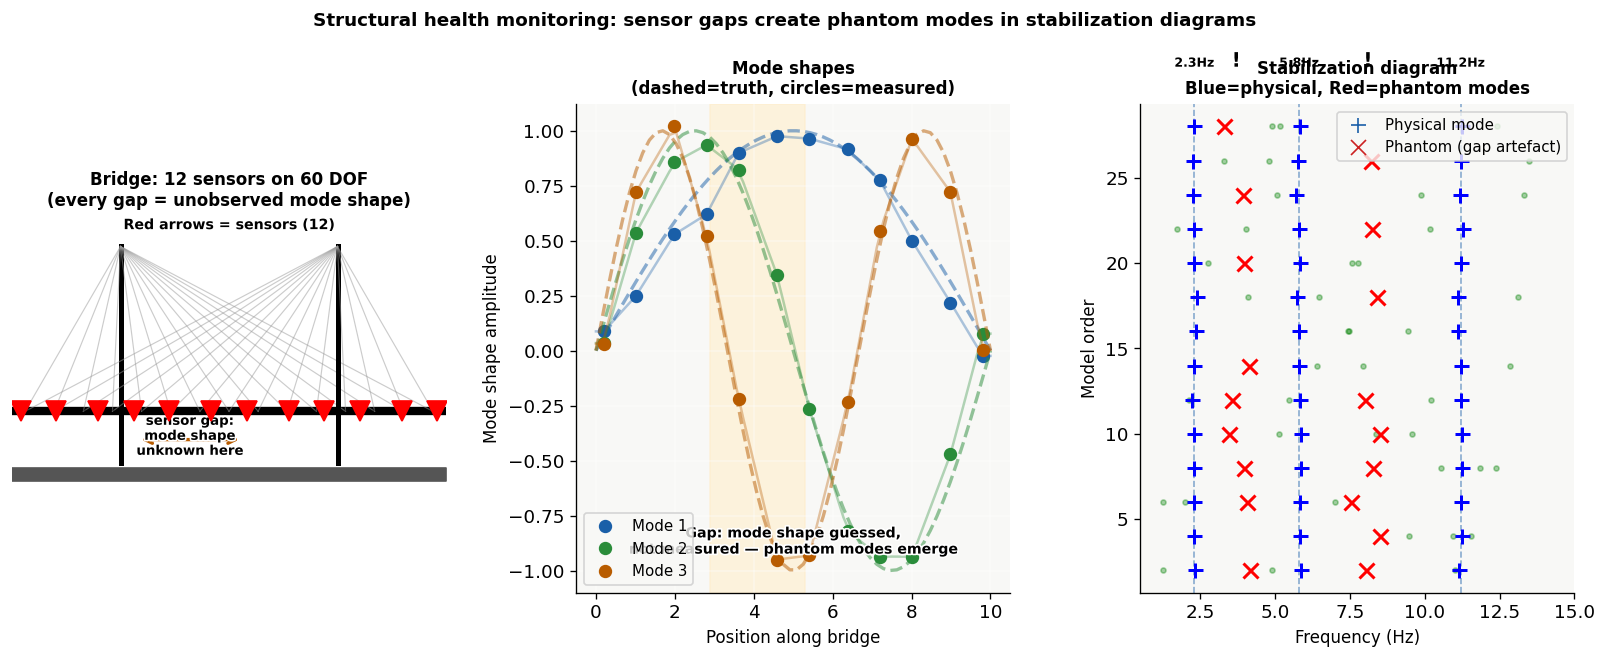

In [13]:
# Structural health monitoring: bridge with sparse sensors + stabilization diagram
np.random.seed(11)
fig=plt.figure(figsize=(14,5.5))
fig.subplots_adjust(left=0.04,right=0.97,top=0.84,bottom=0.10,wspace=0.3)
gs_s=GridSpec(1,3,figure=fig)

# Panel 1: Bridge schematic
ax0=fig.add_subplot(gs_s[0,0])
ax0.set_xlim(0,10); ax0.set_ylim(-1.6,4.5); ax0.set_aspect('equal'); ax0.axis('off')
ax0.set_title('Bridge: 12 sensors on 60 DOF\n(every gap = unobserved mode shape)',fontsize=10,fontweight='bold')
deck_x=np.linspace(0,10,200)
ax0.plot(deck_x,np.zeros_like(deck_x),'k-',lw=5)
for tx in [2.5,7.5]:
    ax0.plot([tx,tx],[-1.2,3.8],'k-',lw=3)
    for cx in np.linspace(0.3,9.7,15):
        ax0.plot([tx,cx],[3.8,0],'#999',lw=0.7,alpha=0.5)
ax0.fill_between([0,10],[-1.6,-1.6],[-1.3,-1.3],color='#555')
n_dof=60; dof_x=np.linspace(0.2,9.8,n_dof)
sensor_idx=np.round(np.linspace(0,n_dof-1,12)).astype(int)
sensor_x=dof_x[sensor_idx]
for xi in dof_x: ax0.plot(xi,0,'k.',ms=4,alpha=0.2)
for xi in sensor_x: ax0.plot(xi,0,'rv',ms=12,zorder=5)
# Gap annotation
gs_lo=sensor_x[3]+0.1; gs_hi=sensor_x[6]-0.1
ax0.annotate('',xy=(gs_hi,-0.65),xytext=(gs_lo,-0.65),
             arrowprops=dict(arrowstyle='<->',color='#b85c00',lw=2))
ax0.text((gs_lo+gs_hi)/2,-1.0,'sensor gap:\nmode shape\nunknown here',
         ha='center',fontsize=8,color='black',fontweight='heavy',
         path_effects=[pe.withStroke(linewidth=2,foreground='white')])
ax0.text(5,4.2,'Red arrows = sensors (12)',ha='center',fontsize=8.5,color='black',fontweight='bold',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# Panel 2: Mode shapes at sensor vs full
ax1=fig.add_subplot(gs_s[0,1])
x_full=np.linspace(0,10,n_dof)
for mn,col,lab in [(1,'#1a5fa8','Mode 1'),(2,'#2a8c3a','Mode 2'),(3,'#b85c00','Mode 3')]:
    phi_true=np.sin(mn*np.pi*x_full/10)
    phi_meas=phi_true[sensor_idx]+0.05*np.random.randn(len(sensor_idx))
    ax1.plot(x_full,phi_true,color=col,lw=2,alpha=0.5,linestyle='--')
    ax1.plot(sensor_x,phi_meas,'o',color=col,ms=7,label=lab)
    ax1.plot(x_full,np.interp(x_full,sensor_x,phi_meas),color=col,lw=1.5,alpha=0.35)
ax1.axvspan(sensor_x[3]+0.1,sensor_x[6]-0.1,color='#ffeecc',alpha=0.6)
ax1.set_xlabel('Position along bridge',fontsize=10)
ax1.set_ylabel('Mode shape amplitude',fontsize=10)
ax1.set_title('Mode shapes\n(dashed=truth, circles=measured)',fontsize=10,fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True,alpha=0.3)
ax1.text(0.5,0.08,'Gap: mode shape guessed,\nnot measured — phantom modes emerge',
    transform=ax1.transAxes,ha='center',fontsize=8.5,color='black',fontweight='heavy',
    path_effects=[pe.withStroke(linewidth=2,foreground='white')])

# Panel 3: Stabilization diagram
ax2=fig.add_subplot(gs_s[0,2])
phys_freqs=[2.3,5.8,11.2]; spur_freqs=[3.7,8.1]
for order in range(2,30,2):
    for f in phys_freqs:
        ax2.plot(f+0.04*np.random.randn(),order,'b+',ms=9,mew=1.8,zorder=3)
    for f in spur_freqs:
        if np.random.rand()<0.55:
            ax2.plot(f+0.35*np.random.randn(),order,'rx',ms=9,mew=1.8,zorder=3)
    for _ in range(3):
        ax2.plot(np.random.uniform(1,14),order,'g.',ms=6,alpha=0.35)
for f in phys_freqs:
    ax2.axvline(f,color='#1a5fa8',lw=1,ls='--',alpha=0.5)
    bold_text(ax2,f,31.5,f'{f}Hz',ha='center',fontsize=7.5,color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
for f in spur_freqs:
    ax2.text(f,31.5,'!',ha='center',fontsize=12,color='black',fontweight='bold',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])
ax2.set_xlabel('Frequency (Hz)',fontsize=10)
ax2.set_ylabel('Model order',fontsize=10)
ax2.set_title('Stabilization diagram\nBlue=physical, Red=phantom modes',fontsize=10,fontweight='bold')
ax2.set_xlim(0.5,15)
ax2.legend(handles=[
    plt.Line2D([],[],marker='+',color='#1a5fa8',lw=0,ms=9,label='Physical mode'),
    plt.Line2D([],[],marker='x',color='#cc2222',lw=0,ms=9,label='Phantom (gap artefact)'),
],fontsize=9)

fig.suptitle('Structural health monitoring: sensor gaps create phantom modes in stabilization diagrams',
             fontsize=11,fontweight='bold')
plt.show()


---
## §7 — Gap-Filling Before Decomposition: The Extrapolation Approach

### 7.1 The Idea

Gap-filling is not one mitigation strategy among equals. It is the observation that the phantom problem disappears entirely if the gap disappears: if the fill is correct, $M$ becomes $I$, $A$ becomes $I$, $K$ vanishes — no coupling, no phantom energy, no conditioning problem. The reason every community has some version of this is not accident; the simplest possible remedy is to eliminate the source of coupling before performing the spectral decomposition.

The rest of this section asks when that is feasible and what determines the quality of the fill. The answer is the concentration operator: its eigenvalue spectrum determines how well the fill can work ($\mu_{\max}$ small means the fill is nearly unique; $\mu_{\max} \approx 1$ means the fill is a guess for the ambiguous direction), and it is the same spectrum that controls inversion stability. Gap-filling and operator inversion are two approaches to the same ill-posed problem, limited by the same concentration eigenvalues.

### 7.2 Papoulis-Gerchberg Iteration

The classical algorithm (Papoulis 1975, Gerchberg 1974) alternates between two constraints: the spatial constraint (known samples must be preserved) and the spectral constraint (the signal is bandlimited to $N$ modes). Starting from $y = Mf$ with zeros in the gap:
$$f^{(k+1)} = P_N\left[y + (I-M)\,f^{(k)}\right]. \tag{12}$$

This iterates toward the minimum-norm bandlimited signal consistent with the observed data. The iteration can be written as a Neumann series. Define the "gap extrapolation operator" $T = (I-M)P_N$. Then:
$$f^{(k)} = \sum_{j=0}^{k-1} T^j P_N y \xrightarrow{k\to\infty} (I-T)^{-1}P_N y = (I - (I-M)P_N)^{-1}P_N y,$$
provided the series converges — i.e., provided the spectral radius $\rho(T) < 1$. Since $T = (I-M)P_N = \chi_G P_N$, its eigenvalues are exactly the eigenvalues of the concentration operator $C_N = P_N\chi_G P_N$: the spectral radius of $T$ is $\mu_{\max}(C_N)$. The Neumann series converges if and only if $\mu_{\max} < 1$.

The convergence rate is geometric in $\mu_{\max}$: after $k$ iterations, the remaining error is bounded by $\mu_{\max}^k$ times the initial error. Near $\mu_{\max} = 1$, convergence is arbitrarily slow. The number of iterations required to reach tolerance $\varepsilon$ scales as $k \sim \log(\varepsilon)/\log(\mu_{\max}) \approx -\varepsilon/\log(\mu_{\max})$, which diverges as $\mu_{\max} \to 1$.

### 7.3 The Fundamental Limitation

Gap-filling is underdetermined. The gap region has zero data. Any bandlimited function matching the measured data outside $G$ and "reasonable" inside $G$ is a valid fill. The concentration operator tells you how bad this ambiguity is: its eigenvalues $\mu_j$ measure how much of a bandlimited signal can hide inside the gap. If $\mu_{\max}$ is small (gap small relative to wavelengths), the fill is nearly unique. If $\mu_{\max} \approx 1$, there exists a bandlimited function living almost entirely inside the gap — the outside data constrains it negligibly, and the fill is essentially a guess for that direction.

This is why $\ell^1$ (sparsity) helps: it breaks the ambiguity by selecting the fill with the fewest active modes. In synthetic tests with exactly sparse excitation, $\ell^1$/ISTA recovery achieves near-zero phantom amplitude even at high condition numbers where linear methods fail. The sparsity prior resolves the underdetermination that defeats Papoulis-Gerchberg — but its practical effectiveness depends on the sparsity assumption holding for the actual signal.

### 7.4 Domain-Specific Variants

**CMB:** inpainting algorithms fill the masked region with constrained Gaussian realizations consistent with the estimated power spectrum. This is a stochastic version of gap-filling, producing ensemble estimates rather than point estimates.

**SAR:** the MPI method uses a first-guess wave spectrum from a numerical model as the initial fill, then iterates. The model spectrum serves as the prior.

**Seismology:** missing-trace interpolation using prediction-error filters (Spitz 1991) or anti-leakage Fourier transform (Xu et al. 2005). These fill gaps in the spatial domain before migration or AVO analysis.

**Structural:** mode shape expansion from sparse sensors to a dense FE mesh using the SEREP (System Equivalent Reduction Expansion Process) method. This uses the FE model as the prior for gap-filling, analogous to the SAR use of wave models.

---
## §8 — The Unified View

### 8.1 One Problem, Five Costumes

The five communities face manifestations of the same structural problem at varying levels of directness. Geodesy (spherical Slepian functions) works with literally the same coefficient-level operators as the phantom framework — the Slepian concentration operator is the phantom framework's $C_N$ on $S^2$. CMB cosmology works with the structurally parallel power-spectrum version: the MASTER matrix is quadratic in the mask and acts on $\hat{C}_\ell$, not on individual $a_{\ell m}$. SAR ocean sensing encounters a structural parallel in wavenumber space. Seismology and structural monitoring face closely related underdetermined inverse problems with the same qualitative features. The common mathematical core is:
$$\hat{c} = Ac, \qquad A = I-K, \qquad K_{mn} = \int_G \varphi_n\bar{\varphi}_m. \tag{13}$$

| Domain | Eigenbasis | Gap | Coupling | Solution |
|--------|-----------|-----|----------|---------|
| CMB | $Y_{\ell m}$ | Sky mask | $M_{\ell\ell'}$ via Wigner 3j | MASTER inversion + apodization |
| Geodesy | $Y_{\ell m}$ | Polar gap / regional boundary | Concentration operator $D$ | Slepian basis projection |
| SAR ocean | Fourier modes | Azimuthal cutoff wedge | Transfer function $T(k)$ | MPI iteration + multi-satellite fusion |
| Seismology | Fourier / curvelet | Missing traces | Sampling operator $\Phi$ | $\ell^1$ compressed sensing + rank reduction |
| Structural | Mode shapes | Unmonitored DOFs | Spatial aliasing in $\Phi_s$ | Stabilization diagrams + roving sensors |

### 8.2 Four Solutions, One Strategy Space

Every solution maps onto one of four strategies, each corresponding to a different way of dealing with the ill-conditioning of $A$:

**Invert $A$ (deconvolution):** compute the coupling matrix from the gap geometry, invert it. CMB's MASTER is the cleanest example. Works when $\kappa(A)$ is moderate. Fails when $\mu_{\max} \approx 1$.

**Change basis (Slepian):** replace the gap-unaware eigenbasis with a gap-aware basis (Slepian functions) that is orthogonal over the observed region. Mathematically equivalent to regularized inversion of $A$, but formulated as a basis change. Geodesy's primary approach.

**Regularize with sparsity ($\ell^1$):** assume the true signal is sparse and solve the underdetermined problem with an $\ell^1$ penalty. Seismology's primary approach. In synthetic tests with exactly sparse excitation, $\ell^1$ recovery remains robust even at condition numbers where linear solvers fail ($\kappa \approx 800$ in the companion script). The practical scope of this advantage depends on the validity of the sparsity assumption.

**Multiple measurements (aperture synthesis):** combine measurements with different gap geometries. Different gaps produce different ill-conditioned directions; the stacked system $[A_1; A_2]c$ has better conditioning. SAR's multi-satellite cutoff compensation. Structural monitoring's roving sensors. Requires the same underlying signal across acquisitions.

### 8.3 Who Models the Instrument Response?

Of the five communities, CMB cosmology and geodesy explicitly model the gap as an instrument response. CMB computes and inverts the coupling matrix as a standard calibration step. Geodesy builds the concentration operator and constructs a gap-aware basis (Slepian functions) — a rigorous operator-theoretic treatment. The SAR, seismology, and structural dynamics communities generally treat the gap as a missing-data problem rather than as an instrument-response problem, though their methods implicitly address the same ill-conditioning.

The practical distinction is between **missing data** (you know less) and **false attribution** (you believe the wrong thing). The CMB and geodesy communities address false attribution directly — by modeling the mask's effect on the spectral decomposition. The other communities address the missing-data side — filling gaps, interpolating traces, adding sensors — which can be equally effective in practice but does not always surface the recognition that the downstream spectral analysis is actively corrupted, not merely degraded.

**Conceptual transfer vs technical transfer.** The cross-domain comparison enables two qualitatively different things.

*Conceptual transfer:* a field understands its own artifacts more clearly through the phantom framework. Seismology and structural monitoring do not compute $K_{mn}$ explicitly, but the phantom framework names what is happening — false modal content generated by deterministic coupling — more precisely than "spatial aliasing" or "spurious stabilization poles." The framework provides a causal account of phenomena that the community treats heuristically.

*Technical transfer:* a field borrows an actual computable tool. CMB's apodization profiles, geodesy's Slepian basis, SAR's multi-satellite conditioning bound — these are deployable tools that the home problem has not yet used. Technical transfer requires genuine operator analogy, not just structural parallel.

CMB and geodesy support both kinds of transfer. SAR supports technical transfer for the multi-measurement stacking principle but not for the nonlinear forward model. Seismology and structural monitoring support primarily conceptual transfer; their specific tools require adaptation before porting.

### 8.4 The Extrapolation Shortcut

Gap-filling before spectral decomposition is the most intuitive approach and is used in every community. If the fill is perfect, the problem disappears. The concentration operator $C_N$ determines how well the fill can work: its largest eigenvalue $\mu_{\max}$ measures the fraction of bandlimited energy that can hide inside the gap, and thus the inherent ambiguity in any gap-filling procedure.

For small gaps ($\mu_{\max} \ll 1$), extrapolation is nearly unique and gap-filling works well. For large gaps ($\mu_{\max} \approx 1$), the fill is fundamentally underdetermined and the choice of prior (sparsity, model spectrum, smoothness) determines the result. In this regime, gap-filling and coupling-matrix inversion converge: both require the same prior information to resolve the ambiguity, and both are limited by the same concentration-operator spectrum.

---

### 8.5 — Design Implications: What Each Domain's Solution Implies for the Home Problem

The five communities' solutions are independent experimental data on what works. Organizing them by mitigation category — (A) weaken the coupling by modeling/inverting the forward operator, (B) redesign the projection/basis to be gap-aware, (C) redistribute information across multiple measurement configurations — reveals both what is well-covered and what is unexploited.

**Mitigation map across domains:**

| Domain | Category A: weaken coupling | Category B: redesign projection | Category C: multi-measurement | What's absent |
|--------|-----------------------------|----------------------------------|-------------------------------|---------------|
| CMB | ✓ MASTER inversion, apodization | — | — (same gap in all channels) | B, C |
| Geodesy | △ Tikhonov threshold | ✓ Slepian basis, mask-adapted projection | △ GRACE + ground combinations | Explicit $K$ inversion |
| SAR ocean | ✓ MPI iteration + model prior | — | ✓ Multi-satellite cutoff fusion | Cutoff apodization |
| Seismology | — | ✓ $\ell^1$/sparsity, random sampling | — | Explicit $K$ computation |
| Structural | — | — | ✓ Roving sensors | A, B entirely; detection ≠ mitigation |

(✓ = primary strategy · △ = partial or implicit · — = absent)

**Four specific consequences for the home problem:**

**From CMB — apodization as optimization.** The optimal taper profile for the home problem minimizes $\int \psi(1-\psi)|\varphi_n|^2$ subject to a constraint on effective bandwidth loss from the taper support. This is a well-posed optimization problem. CMB has studied it with specific profiles (tophat, cosine, Gaussian, $C^\infty$ bumps), with quantitative comparisons of coupling sidelobe suppression vs effective sky area. The phantom mitigation document states the tradeoff qualitatively; CMB's literature makes it computable. The design criterion should be imported directly.

**From geodesy — the Shannon number as a single diagnostic.** $N_{\text{Shannon}} = (L+1)^2 - \mathrm{tr}(C_N)$ is a better single summary of observable capacity than the condition number $\kappa(A)$. Here $\mathrm{tr}(C_N) = \sum_j \mu_j$ measures the total energy the gap captures across all modes (the *gap capacity*), so $(L+1)^2 - \mathrm{tr}(C_N)$ is the total observable capacity. Note: geodesy uses the concentration operator $D = P_N - C_N$ for the data region, and $\mathrm{tr}(D) = N_{\text{Shannon}}$; the phantom framework's $C_N$ integrates over the gap, so $\mathrm{tr}(C_N)$ and $N_{\text{Shannon}}$ are complementary quantities summing to $(L+1)^2$. Adding both $\mathrm{tr}(C_N)$ (gap capacity) and $N_{\text{Shannon}} = (L+1)^2 - \mathrm{tr}(C_N)$ (observable capacity) as diagnostics to the companion's §1 would immediately quantify how many independent degrees of freedom survive any gap configuration.

**From SAR — maximize $\theta_{12}$ for multi-gap design.** The principal angle $\theta_{12}$ between the two configurations' near-null subspaces in mode space is the controlling parameter — more important than gap sizes individually. The design criterion for the home problem: choose gap positions whose near-1 eigenvectors of $C_N$ are as far apart as possible (maximize $\theta_{12}$). This converts the qualitative "transversality" criterion in mitigation.ipynb into a geometric design target. *(Note: the formula $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)\sin\theta_{12}$ stated in §4.4 is vacuous when $\sigma_{\min}(A_1)$ is small — precisely the regime where the improvement matters. The $\theta_{12}$ criterion is the correct design principle; the bound does not capture the actual gain.)*

**From seismology — dithering as a Category C strategy.** Where some control over gap placement exists, randomizing the gap boundary position decorrelates the off-diagonal entries of $K$ even without multiple measurements. If the gap centroid is uncertain within a tolerance band $\Delta x$, the effective $K$ is an average over a family of coupling matrices with different phases, which destructively interferes the off-diagonal entries. This requires only that positional tolerance be exploited rather than suppressed. It is a Category C strategy available in single-measurement settings and is not currently in mitigation.ipynb.


---

---

### 8.6 — What the Unified Framework Might Offer Back

The framing so far has been one-directional: each community's solution as a source of insight for the home problem. The direction can be reversed. If the phantom framework is a more complete theory of this phenomenon than any single community has developed, some of its tools might be useful in those communities — not as corrections, but as additions.

Five candidates are identified below. Each is framed as an investigation direction. Whether any of these tools already exist in a given community in equivalent form is something worth checking before claiming a gap.

**The energy identity as a real-time diagnostic.** The exact identity $\sum_{m\neq n}|\hat{c}_m|^2 = |c_n|^2 a_n(1-a_n)$ makes a specific quantitative prediction: given a known gap geometry and a candidate true mode, the total phantom energy in the measured spectrum is computable before looking at the data. It would be worth asking whether CMB or geodesy uses this identity explicitly as a consistency check — not just to invert the coupling matrix, but to flag whether a given spectral estimate is consistent with what the gap geometry predicts independently. In seismology and structural monitoring, where the coupling matrix is not typically computed, this check is not currently available. Whether it would catch real errors in practice is a genuine empirical question.

**The $w_G / s_{G,N}$ distinction and what it implies for windowing.** The decomposition into the exact modal lie $w_G$ (uniform, nondecaying, independent of bandwidth) and the finite-band artifact $s_{G,N}$ (Gibbs-localized near $\partial G$; its main-lobe width shrinks as $O(\Lambda^{-1})$ with bandwidth, but its amplitude at $\partial G$ does not vanish — $\Gamma(0) = 1/2$ regardless of $\Lambda$, and global oscillatory sidelobes persist) may not be explicit in any of the five communities. CMB apodization addresses the sidelobes of $s_{G,N}$ but may not distinguish them from $w_G$. The practical implication is that $w_G$ does not improve with better windowing or higher bandwidth — only inverting $A$ removes it. Whether this distinction changes the interpretation of apodization results in CMB, or the convergence guarantees in seismic interpolation, is worth investigating.

**Nodal placement as an explicit design rule.** Aligning a measurement gap's cross-section with a nodal line of the mode of interest drives $a_n \to 0$ by geometry. Scaling (small-gap limit): $a_n = O(d^2 + a^2)$ where $d$ is centroid distance from the nodal line and $a$ is gap width in the crossing direction — **not** independent of gap size, but suppressed by one order relative to a generic placement. This is a leading-order design criterion from the phantom framework. It would be interesting to check whether any of the five communities uses an equivalent criterion explicitly — CMB mask boundaries relative to spherical harmonic nodal structure, or sensor placement relative to structural mode shape nodes in OMA. If not, the criterion is directly transferable as a design heuristic. If so, the connection is worth making explicit.

**The concentration operator spectrum as a recovery capacity measure.** Geodesy makes the Slepian eigenvalues of $C_N$ the primary object; the Shannon number $\mathrm{tr}(C_N)$ gives the effective dimension of the observable subspace as a single number. The other four communities don't appear to use an equivalent quantity. For a SAR operator choosing between satellite configurations, or a structural engineer comparing sensor layouts, $\mathrm{tr}(C_N)$ would immediately quantify how many independent degrees of freedom each configuration can recover — independently of what signal is present. Whether the seismic or structural communities have equivalent quantities under different names, and whether adopting this framing would change practical decisions, is worth looking into.

**Transversality as a placement criterion.** The principal angle $\theta_{12}$ between the two configurations' ill-conditioned subspaces is the right design target: larger $\theta_{12}$ → better stacked conditioning. The bound $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)\sin\theta_{12}$ from §4.4 gives the correct qualitative direction but is vacuous when $\sigma_{\min}(A_1)$ is already small (it's always weaker than the trivial $\sigma_{\min}([A_1;A_2]) \geq \sigma_{\min}(A_1)$), so the numerical gain from $\theta_{12}$ is not captured. The exact form of the gain is open theorem T9. SAR's multi-satellite fusion and structural monitoring's roving sensors both use multi-measurement synthesis, but the choice of configurations appears to be driven by practical constraints rather than this geometric criterion. Whether an explicit $\theta_{12}$-maximizing criterion would change satellite look angles or sensor placements is a natural investigation direction.
---
## §9 — Conclusion

The hole causes the problem. This is not a metaphor. It is a mathematical identity: the coupling matrix $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$ is a property of the hole geometry, and the corrupted coefficients $\hat{c} = Ac$ follow deterministically from $K$ and the true signal $c$.

Five communities have independently encountered this problem at varying levels of explicitness. CMB cosmology addressed it most directly, computing and inverting the coupling matrix as a calibration step since 2002. Geodesy built the deepest mathematical treatment, making the concentration operator the primary object and constructing gap-aware bases from its eigenvectors. SAR ocean sensing developed multi-satellite aperture synthesis to compensate directional gaps. Seismology adopted compressed sensing for missing-trace recovery — a closely related underdetermined inverse problem with convergent solution strategies. Structural monitoring developed heuristic detection methods (stabilization diagrams, roving sensors) that implicitly address the same phenomenon without the explicit operator framework.

The domains don't talk to each other. The geodesist building Slepian functions is literally solving $\hat{c} = Ac$ with explicit $A$. The CMB analyst inverting the MASTER matrix is solving the structurally parallel **power-spectrum** version of the same gap-inversion problem (quadratic in the mask, acting on $\hat{C}_\ell$ rather than on coefficients). The SAR engineer fusing multi-satellite spectra is solving the coefficient-level equation in the spectral domain with an approximately equivalent $A$. The seismologist running $\ell^1$ reconstruction and the structural engineer studying stabilization diagrams are addressing the same underlying ill-posed inverse problem but without assembling $A$ explicitly — their connection to the framework is structural, not computational. Domain-specific tools, domain-specific priors, and domain-specific names for overlapping mathematical objects.

The unified message: a measurement gap is part of the instrument. Its geometry fixes a deterministic forward operator before any data arrive. Ignoring that operator does not produce uncertainty; it produces structured false attribution — phantom spectral content that is coherent, deterministic, and indistinguishable from real signal without independent knowledge of the mask. The remedy, in every domain, is the same: model the instrument response, and either invert it, regularize it, or design around it.


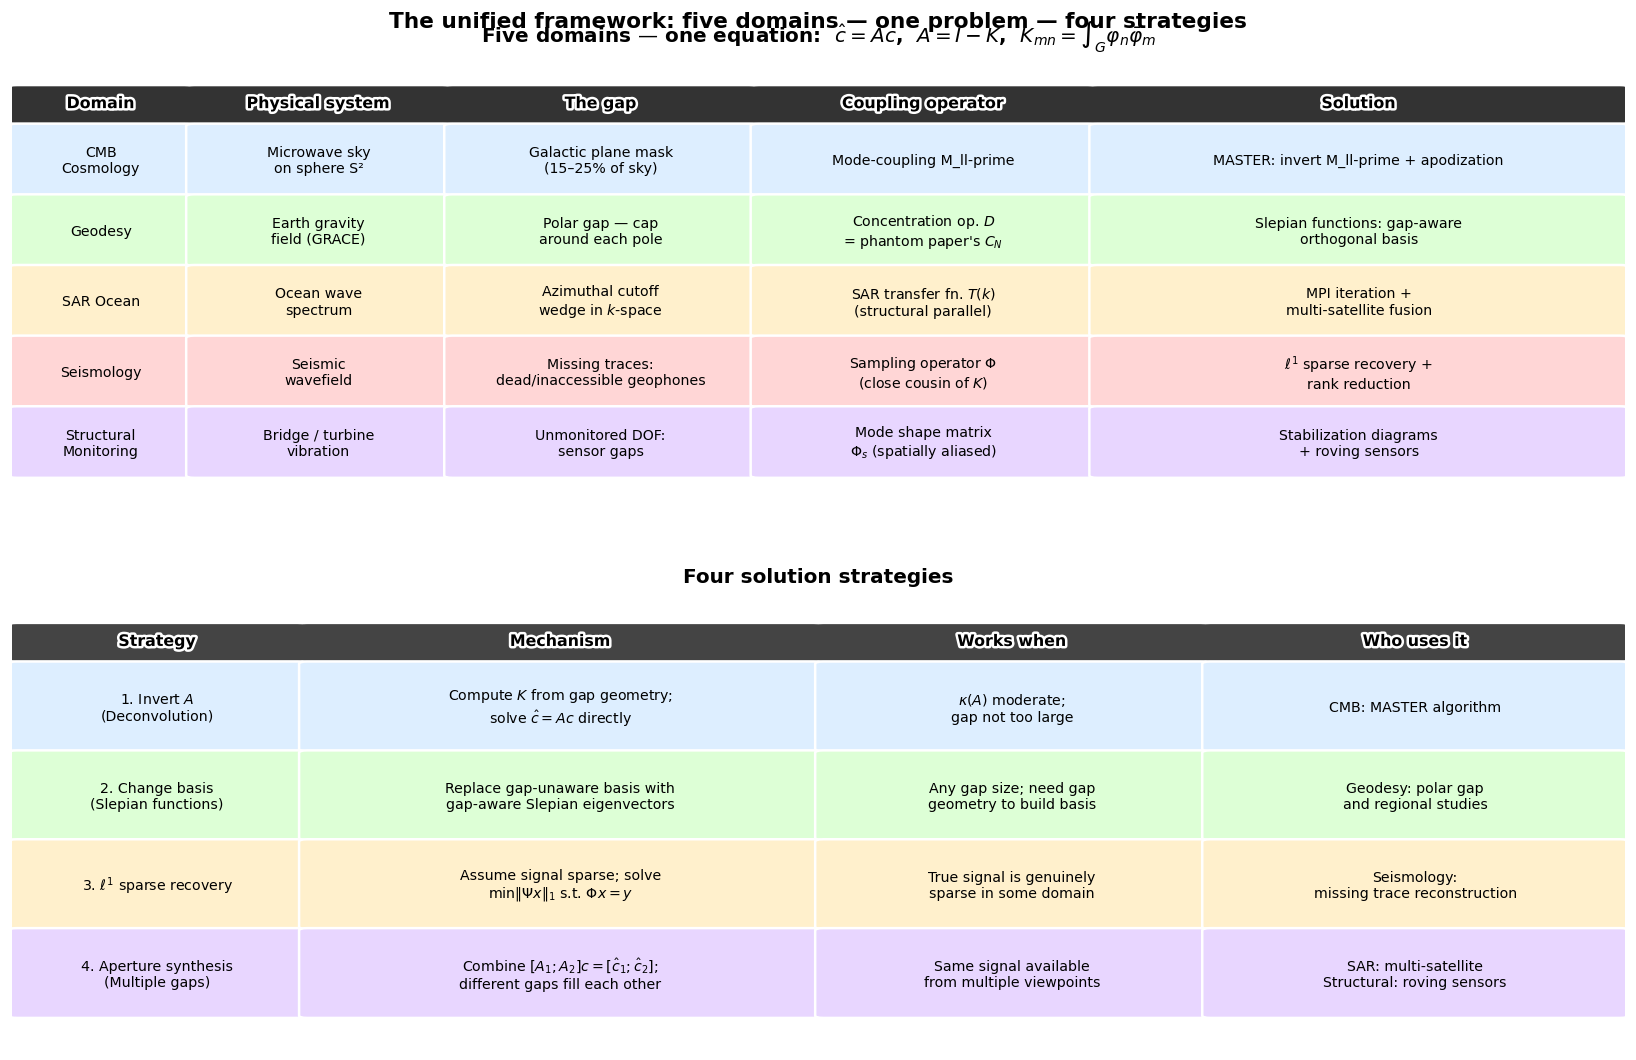

In [14]:
import matplotlib.patheffects as pe
# Unified view: two clean tables
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.02, hspace=0.18)

for ax in axes:
    ax.axis('off')
    ax.set_xlim(0, 1)

# ── Table 1: Domain mapping ──────────────────────────────────────────────
ax = axes[0]
ax.set_ylim(0, 1)
ax.set_title('Five domains — one structural template:  $\\hat{c} = Ac$,  $A = I-K$  '
             r'(literal for geodesy; power-spectrum analogue for CMB; structural for SAR/seismology/structural)',
             fontsize=11, fontweight='bold', pad=6)

headers  = ['Domain', 'Physical system', 'The gap', 'Coupling operator', 'Solution']
col_x    = [0.00, 0.11, 0.27, 0.46, 0.67]
col_w    = [0.11, 0.16, 0.19, 0.21, 0.33]
row_bg   = ['#ddeeff', '#ddffd6', '#fff0cc', '#ffd6d6', '#e8d6ff']
rows = [
    ('CMB\nCosmology',    'Microwave sky\non sphere S²',
     'Galactic plane mask\n(15–25% of sky)',
     'Mode-coupling M_ll-prime',
     'MASTER: invert M_ll-prime + apodization'),
    ('Geodesy',           'Earth gravity\nfield (GRACE)',
     'Polar gap — cap\naround each pole',
     'Concentration op. $D$\n= phantom paper\'s $C_N$',
     'Slepian functions: gap-aware\northogonal basis'),
    ('SAR Ocean',         'Ocean wave\nspectrum',
     'Azimuthal cutoff\nwedge in $k$-space',
     'SAR transfer fn. $T(k)$\n(structural parallel)',
     'MPI iteration +\nmulti-satellite fusion'),
    ('Seismology',        'Seismic\nwavefield',
     'Missing traces:\ndead/inaccessible geophones',
     'Sampling operator $\\Phi$\n(close cousin of $K$)',
     r'$\ell^1$ sparse recovery +' + '\nrank reduction'),
    ('Structural\nMonitoring', 'Bridge / turbine\nvibration',
     'Unmonitored DOF:\nsensor gaps',
     'Mode shape matrix\n$\\Phi_s$ (spatially aliased)',
     'Stabilization diagrams\n+ roving sensors'),
]

# Header row
y_hdr = 0.93
for (hdr, cx, cw) in zip(headers, col_x, col_w):
    ax.add_patch(mpatches.FancyBboxPatch((cx+0.003, y_hdr-0.075), cw-0.006, 0.07,
        boxstyle='round,pad=0.005', fc='#333', ec='none'))
    ax.text(cx+cw/2, y_hdr-0.038, hdr, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

# Data rows
row_h = 0.155
for i, (row, bg) in enumerate(zip(rows, row_bg)):
    y_top = y_hdr - 0.085 - i*row_h
    for j, (cell, cx, cw) in enumerate(zip(row, col_x, col_w)):
        ax.add_patch(mpatches.FancyBboxPatch((cx+0.003, y_top-row_h+0.006), cw-0.006, row_h-0.008,
            boxstyle='round,pad=0.005', fc=bg, ec='white', linewidth=1.5))
        ax.text(cx+cw/2, y_top-row_h/2, cell, ha='center', va='center',
                fontsize=8.5, multialignment='center')

# ── Table 2: Four strategies ──────────────────────────────────────────────
ax2 = axes[1]
ax2.set_ylim(0, 1)
ax2.set_title('Four solution strategies', fontsize=12, fontweight='bold', pad=6)

strat_headers = ['Strategy', 'Mechanism', 'Works when', 'Who uses it']
strat_col_x   = [0.00, 0.18, 0.50, 0.74]
strat_col_w   = [0.18, 0.32, 0.24, 0.26]
strat_bg      = ['#ddeeff', '#ddffd6', '#fff0cc', '#e8d6ff']
strategies = [
    ('1. Invert $A$\n(Deconvolution)',
     'Compute $K$ from gap geometry;\nsolve $\\hat{c}=Ac$ directly',
     r'$\kappa(A)$ moderate;' + '\ngap not too large',
     'CMB: MASTER algorithm'),
    ('2. Change basis\n(Slepian functions)',
     'Replace gap-unaware basis with\ngap-aware Slepian eigenvectors',
     'Any gap size; need gap\ngeometry to build basis',
     'Geodesy: polar gap\nand regional studies'),
    (r'3. $\ell^1$ sparse recovery',
     'Assume signal sparse; solve\n$\\min\\|\\Psi x\\|_1$ s.t. $\\Phi x=y$',
     'True signal is genuinely\nsparse in some domain',
     'Seismology:\nmissing trace reconstruction'),
    ('4. Aperture synthesis\n(Multiple gaps)',
     'Combine $[A_1;A_2]c=[\\hat{c}_1;\\hat{c}_2]$;\ndifferent gaps fill each other',
     'Same signal available\nfrom multiple viewpoints',
     'SAR: multi-satellite\nStructural: roving sensors'),
]

# Header
y_hdr2 = 0.93
for (hdr, cx, cw) in zip(strat_headers, strat_col_x, strat_col_w):
    ax2.add_patch(mpatches.FancyBboxPatch((cx+0.003, y_hdr2-0.075), cw-0.006, 0.07,
        boxstyle='round,pad=0.005', fc='#444', ec='none'))
    ax2.text(cx+cw/2, y_hdr2-0.038, hdr, ha='center', va='center',
             fontsize=9.5, fontweight='bold', color='black',
            path_effects=[pe.withStroke(linewidth=3, foreground='white')])

row_h2 = 0.195
for i, (row, bg) in enumerate(zip(strategies, strat_bg)):
    y_top = y_hdr2 - 0.085 - i*row_h2
    for j, (cell, cx, cw) in enumerate(zip(row, strat_col_x, strat_col_w)):
        ax2.add_patch(mpatches.FancyBboxPatch((cx+0.003, y_top-row_h2+0.006), cw-0.006, row_h2-0.008,
            boxstyle='round,pad=0.005', fc=bg, ec='white', linewidth=1.5))
        ax2.text(cx+cw/2, y_top-row_h2/2, cell, ha='center', va='center',
                 fontsize=8.5, multialignment='center')

fig.suptitle('The unified framework: five domains — one problem — four strategies',
             fontsize=13, fontweight='bold')
plt.show()


---
## References

1. Hivon, E. et al. MASTER of the CMB Anisotropy Power Spectrum. *Astrophys. J.*, 567, 2–17 (2002).
2. Simons, F.J., Dahlen, F.A., & Wieczorek, M.A. Spatiospectral concentration on a sphere. *SIAM Review*, 48(3), 504–536 (2006).
3. Simons, F.J. & Dahlen, F.A. Spherical Slepian functions and the polar gap in geodesy. *Geophys. J. Int.*, 166, 1039–1061 (2006).
4. Slepian, D. & Pollak, H.O. Prolate spheroidal wave functions, Fourier analysis and uncertainty — I. *Bell Syst. Tech. J.*, 40(1), 43–63 (1961).
5. Hasselmann, S. & Hasselmann, K. On the nonlinear mapping of an ocean wave spectrum into a SAR image spectrum. *J. Geophys. Res.*, 96(C6), 10713–10729 (1991).
6. Papoulis, A. A new algorithm in spectral analysis and band-limited extrapolation. *IEEE Trans. Circuits Syst.*, 22(9), 735–742 (1975).
7. Gerchberg, R.W. Super-resolution through error energy reduction. *Optica Acta*, 21(9), 709–720 (1974).
8. Candès, E.J. & Wakin, M.B. An introduction to compressive sampling. *IEEE Signal Processing Magazine*, 25(2), 21–30 (2008).
9. Harris, F.J. On the use of windows for harmonic analysis with the discrete Fourier transform. *Proc. IEEE*, 66(1), 51–83 (1978).
10. Chen, Y. et al. Obtaining free USArray data by multi-dimensional seismic reconstruction. *Nature Communications*, 10, 4434 (2019).
11. Spitz, S. Seismic trace interpolation in the F-X domain. *Geophysics*, 56(6), 785–794 (1991).
12. Wan, Y. et al. Azimuth cutoff compensation method for SAR wave observation based on multiview wave spectrum data fusion. *IEEE Access*, 8, 120923–120935 (2020).
13. Yoshida, T. Azimuthal ocean wave emerged in SAR image spectra under specific condition. *J. Geophys. Res. Oceans*, 122, 2017JC013096 (2017).
14. Portilla-Yandún, J. et al. Assessment of ocean wave spectrum from SAR data. *Remote Sens. Environ.*, 261, 112516 (2021).
15. O'Connell, K. et al. An energy-based modal assurance criterion for mode assignment in FEM updating. *Mech. Syst. Signal Process.*
